# Actividad - Proyecto práctico


> La actividad se desarrollará en grupos pre-definidos de 4 alumnos. Se debe indicar los nombres en orden alfabético (de apellidos). Recordad que esta actividad se corresponde con un 30% de la nota final de la asignatura. Se debe entregar entregar el trabajo en la presente notebook.
*   Alumno 1:
*   Alumno 2:
*   Alumno 3:
*   Alumno 4:






---
## **PARTE 1** - Instalación y requisitos previos

> Las prácticas han sido preparadas para poder realizarse en el entorno de trabajo de Google Colab. Sin embargo, esta plataforma presenta ciertas incompatibilidades a la hora de visualizar la renderización en gym. Por ello, para obtener estas visualizaciones, se deberá trasladar el entorno de trabajo a local. Por ello, el presente dosier presenta instrucciones para poder trabajar en ambos entornos. Siga los siguientes pasos para un correcto funcionamiento:
1.   **LOCAL:** Preparar el enviroment, siguiendo las intrucciones detalladas en la sección *1.1.Preparar enviroment*.
2.  **AMBOS:** Modificar las variables "mount" y "drive_mount" a la carpeta de trabajo en drive en el caso de estar en Colab, y ejecturar la celda *1.2.Localizar entorno de trabajo*.
3. **COLAB:** se deberá ejecutar las celdas correspondientes al montaje de la carpeta de trabajo en Drive. Esta corresponde a la sección *1.3.Montar carpeta de datos local*.
4.  **AMBOS:** Instalar las librerías necesarias, siguiendo la sección *1.4.Instalar librerías necesarias*.


---
### 1.1. Preparar enviroment (solo local)



> Para preparar el entorno de trabajo en local, se han seguido los siguientes pasos:
1. En Windows, puede ser necesario instalar las C++ Build Tools. Para ello, siga los siguientes pasos. Alternativamente puedes utilizar WSL2: https://towardsdatascience.com/how-to-install-openai-gym-in-a-windows-environment-338969e24d30.
2. Instalar Anaconda
3. Siguiendo el código que se presenta comentado en la próxima celda: Crear un enviroment, cambiar la ruta de trabajo, e instalar librerías básicas.


```
conda create --name miar_rl python=3.8
conda activate miar_rl
cd "PATH_TO_FOLDER"
conda install git
pip install jupyter
```


4. Abrir la notebook con *jupyter-notebook*.



```
jupyter-notebook
```


---
### 1.2. Localizar entorno de trabajo: Google colab o local

In [45]:
# ATENCIÓN!! Modificar ruta relativa a la práctica si es distinta (drive_root)
mount='/content/gdrive'
drive_root = mount + "/My Drive/VIU_Apr_por_Refuerzo_Grupo_17_2025_2026/checkpoints"

try:
  from google.colab import drive
  IN_COLAB=True
except:
  IN_COLAB=False

---
### 1.3. Montar carpeta de datos local (solo Colab)

In [46]:
# Montamos Drive y fijamos el directorio de trabajo a una carpeta DENTRO de
# Drive (drive_root). Esto es importante para entrenamientos largos (varias
# horas, dejados corriendo sin supervisión): si el runtime de Colab se
# desconecta o se recicla, todo lo que esté solo en el disco local del
# runtime (/content/...) se pierde para siempre. Drive, en cambio, persiste
# independientemente de lo que le pase al runtime.
#
# Nota: el propio mount de Drive puede a veces tardar o pedir reautorización
# en VSCode; si la celda se queda colgada en drive.mount(), revisa si apareció
# una ventana/pestaña de autorización de Google que necesite tu confirmación.
import os

if IN_COLAB:
    print("We're running Colab")
    drive.mount(mount)
    os.makedirs(drive_root, exist_ok=True)
    print("\nColab: Changing directory to", drive_root)
    os.chdir(drive_root)
else:
    print("No estamos en Colab (IN_COLAB=False); se usará el directorio actual del kernel.")

WORK_DIR = os.getcwd()
print("\nDirectorio de trabajo actual:", WORK_DIR)
print("Archivos en el directorio:")
print(os.listdir(WORK_DIR))

# Carpetas de salida, una por propuesta, directamente dentro de drive_root
# (.../VIU_Apr_por_Refuerzo_Grupo_17_2025_2026/checkpoints/). Los checkpoints
# intermedios (ModelIntervalCheckpoint) y los logs se escriben aquí durante
# el entrenamiento, así que sobreviven a una desconexión del runtime.
RESULTS_DIR = WORK_DIR
WEIGHTS_DIR_P1 = os.path.join(RESULTS_DIR, 'p1_eps_fijo')
WEIGHTS_DIR_P2 = os.path.join(RESULTS_DIR, 'p2_annealed')
WEIGHTS_DIR_P3 = os.path.join(RESULTS_DIR, 'p3_boltzmann')
WEIGHTS_DIR_P4 = os.path.join(RESULTS_DIR, 'p4_double_dqn')
WEIGHTS_DIR_P5 = os.path.join(RESULTS_DIR, 'p5_dueling_dqn')
WEIGHTS_DIR_P6 = os.path.join(RESULTS_DIR, 'p6_double_dueling')
WEIGHTS_DIR_P7 = os.path.join(RESULTS_DIR, 'p7_double_dqn_annealed')
WEIGHTS_DIR_P8 = os.path.join(RESULTS_DIR, 'p8_dueling_dqn_annealed')

for d in [RESULTS_DIR, WEIGHTS_DIR_P1, WEIGHTS_DIR_P2, WEIGHTS_DIR_P3,
          WEIGHTS_DIR_P4, WEIGHTS_DIR_P5, WEIGHTS_DIR_P6, WEIGHTS_DIR_P7, WEIGHTS_DIR_P8]:
    os.makedirs(d, exist_ok=True)

print("\nCarpetas de checkpoints preparadas (en Drive):")
print(" -", WEIGHTS_DIR_P1)
print(" -", WEIGHTS_DIR_P2)
print(" -", WEIGHTS_DIR_P3)
print(" -", WEIGHTS_DIR_P4)
print(" -", WEIGHTS_DIR_P5)
print(" -", WEIGHTS_DIR_P6)
print(" -", WEIGHTS_DIR_P7)
print(" -", WEIGHTS_DIR_P8)

We're running Colab
Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).

Colab: Changing directory to /content/gdrive/My Drive/VIU_Apr_por_Refuerzo_Grupo_17_2025_2026/checkpoints

Directorio de trabajo actual: /content/gdrive/My Drive/VIU_Apr_por_Refuerzo_Grupo_17_2025_2026/checkpoints
Archivos en el directorio:
['resultados_enduro_dqn', 'p1_eps_fijo', 'p2_annealed', 'p3_boltzmann', 'p4_double_dqn', 'p5_dueling_dqn', 'p6_double_dueling', 'p7_double_dqn_annealed', 'p8_dueling_dqn_annealed']

Carpetas de checkpoints preparadas (en Drive):
 - /content/gdrive/My Drive/VIU_Apr_por_Refuerzo_Grupo_17_2025_2026/checkpoints/p1_eps_fijo
 - /content/gdrive/My Drive/VIU_Apr_por_Refuerzo_Grupo_17_2025_2026/checkpoints/p2_annealed
 - /content/gdrive/My Drive/VIU_Apr_por_Refuerzo_Grupo_17_2025_2026/checkpoints/p3_boltzmann
 - /content/gdrive/My Drive/VIU_Apr_por_Refuerzo_Grupo_17_2025_2026/checkpoints/p4_double_dqn
 - /con

---
### 1.4. Instalar librerías necesarias

In [47]:
if IN_COLAB:
  %pip install tensorflow
  %pip install tf-keras
  # %pip install tensorflow==2.18.0
  # %pip install tf-keras==2.18.0
  %pip install gym==0.17.3
  %pip install git+https://github.com/Kojoley/atari-py.git
  %pip install keras-rl2==1.0.5
  %pip install --upgrade ml_dtypes
else:
  %pip install gym==0.17.3
  %pip install git+https://github.com/Kojoley/atari-py.git
  %pip install pyglet==1.5.0
  %pip install h5py==3.1.0
  %pip install Pillow==9.5.0
  %pip install keras-rl2==1.0.5
  %pip install Keras==2.2.4
  %pip install tensorflow==2.5.3
  %pip install torch==2.0.1
  %pip install agents==1.4.0

  Cloning https://github.com/Kojoley/atari-py.git to /tmp/pip-req-build-o5isa_te
  Running command git clone --filter=blob:none --quiet https://github.com/Kojoley/atari-py.git /tmp/pip-req-build-o5isa_te
  Resolved https://github.com/Kojoley/atari-py.git to commit 86a1e05c0a95e9e6233c3a413521fdb34ca8a089
  Preparing metadata (setup.py) ... done


---
## **PARTE 2**. Enunciado

Consideraciones a tener en cuenta:

- El entorno sobre el que trabajaremos será el indicado en el listado correspondien de cada grupo y el algoritmo que usaremos será _DQN_.

- Para nuestro ejercicio, el requisito mínimo será alcanzado cuando el agente consiga una **media de recompensa por encima de los puntos indicados en el listado por grupos en modo test**. Por ello, esta media de la recompensa se calculará a partir del código de test en la última celda del notebook.

Este proyecto práctico consta de tres partes:

1.   Implementar la red neuronal que se usará en la solución
2.   Implementar las distintas piezas de la solución DQN y probar al menos 3 propuestas diferentes de mejora.
3.   Justificar la respuesta en relación a los resultados obtenidos e incluir al menos 3 gráficas relevantes comparando las 3 propuestas.

**Rúbrica**: Se valorará la originalidad en la solución aportada, así como la capacidad de discutir los resultados de forma detallada. El requisito mínimo servirá para aprobar la actividad, bajo premisa de que la discusión del resultado sera apropiada.

IMPORTANTE:

* Si no se consigue una puntuación óptima, responder sobre la mejor puntuación obtenida.
* Para entrenamientos largos, recordad que podéis usar checkpoints de vuestros modelos para retomar los entrenamientos. En este caso, recordad cambiar los parámetros adecuadamente (sobre todo los relacionados con el proceso de exploración).
* Se deberá entregar unicamente el notebook y los pesos del mejor modelo en un fichero .zip, de forma organizada.
* Cada alumno deberá de subir la solución de forma individual.

---
## **PARTE 3**. Desarrollo y preguntas

#### Importar librerías

In [48]:
#Comprobamos que se carga la versión esperada de TF y detecta la GPU
import os

os.environ['TF_USE_LEGACY_KERAS']="1"

import tensorflow.keras as tf
import tensorflow as tf1

from keras import __version__
tf.__version__ = __version__

print(tf1.__version__)
print(tf1.config.list_physical_devices('GPU'))
print(tf1.config.list_logical_devices('GPU'))

2.19.0
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
[LogicalDevice(name='/device:GPU:0', device_type='GPU')]


In [49]:
from __future__ import division

from PIL import Image
import numpy as np
import gym

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation, Flatten, Convolution2D, Permute

if IN_COLAB:
  from tensorflow.keras.optimizers.legacy import Adam
else:
  from tensorflow.keras.optimizers import Adam

import tensorflow.keras.backend as K

from rl.agents.dqn import DQNAgent
from rl.policy import LinearAnnealedPolicy, BoltzmannQPolicy, EpsGreedyQPolicy
from rl.memory import SequentialMemory
from rl.core import Processor
from rl.callbacks import FileLogger, ModelIntervalCheckpoint

#### Parche parar keras-r12

In [50]:
# ----------------------------------------------------------------------
# PARCHE NECESARIO: keras-rl2 (rl.core.Agent.fit) inicializa el contador de
# pasos como np.int16:
#     self.step = np.int16(0)
# np.int16 solo soporta valores hasta 32767. En entrenamientos largos como
# los que necesitamos aquí (NB_STEPS_TRAIN en el orden de 10^6), en cuanto
# self.step supera 32767 se produce un overflow silencioso (wraparound):
# self.step se vuelve NEGATIVO de golpe.
#
# Esto NO detiene el entrenamiento (la red sigue actualizándose), pero rompe:
#   - La condición 'while self.step < nb_steps' (el conteo real de progreso
#     queda corrupto a partir de ese punto).
#   - LinearAnnealedPolicy.get_current_value(), que calcula epsilon como
#     una función lineal de self.step: con self.step negativo, epsilon
#     puede dispararse por ENCIMA de 1.0 (no hay tope superior en el
#     código), forzando una política de exploración prácticamente
#     aleatoria de forma permanente. Esto explica por qué, tras el aviso
#     de overflow, el reward se desploma a 0 y ya no se recupera.
#   - El logging por intervalos y los ModelIntervalCheckpoint, que también
#     comparan contra self.step.
#
# Solución: forzamos a que el contador interno use un entero de 64 bits
# (np.int64), que aguanta hasta 9.2*10^18, muy por encima de cualquier
# nb_steps razonable. Esto se hace sustituyendo la referencia a np.int16
# que usa el módulo rl.core en tiempo de ejecución (no es necesario tocar
# el código fuente de la librería).
import rl.core as rl_core
rl_core.np.int16 = np.int64
# ----------------------------------------------------------------------

In [51]:
# ----------------------------------------------------------------------
# FIX NECESARIO solo si vas a usar Dueling DQN (enable_dueling_network=True,
# ver Propuesta 4 más abajo): keras-rl2 construye la cabeza dueling con una
# capa Lambda que contiene una función lambda de Python. Al compilar el
# agente, keras-rl2 necesita clonar el modelo (para crear la red objetivo),
# y las versiones modernas de tf_keras bloquean por seguridad la
# deserialización de capas Lambda con lambdas de Python, salvo que se
# habilite explícitamente. Esto no afecta a Double DQN por sí solo, solo
# cuando se combina con Dueling.
import tf_keras
tf_keras.__internal__.enable_unsafe_deserialization()
# ----------------------------------------------------------------------

#### Configuración base

In [52]:
INPUT_SHAPE = (84, 84)
WINDOW_LENGTH = 4

env_name = 'Enduro-v0'
env = gym.make(env_name)

np.random.seed(123)
env.seed(123)
nb_actions = env.action_space.n

print("Entorno:", env_name)
print("Número de acciones disponibles:", nb_actions)
print("Significado de las acciones:", env.unwrapped.get_action_meanings())
print("Formato de las observaciones:", env.observation_space)

Entorno: Enduro-v0
Número de acciones disponibles: 9
Significado de las acciones: ['NOOP', 'FIRE', 'RIGHT', 'LEFT', 'DOWN', 'DOWNRIGHT', 'DOWNLEFT', 'RIGHTFIRE', 'LEFTFIRE']
Formato de las observaciones: Box(0, 255, (210, 160, 3), uint8)


##### Atari Processor

In [53]:
class AtariProcessor(Processor):
    """
    Procesador de observaciones y recompensas para Enduro.

    A diferencia del ejemplo de Breakout, en Enduro:
      - El reward es MUY disperso: solo se obtiene +1 por cada coche adelantado.
      - No existe penalización explícita por choque o por ir despacio:
        cuando el coche choca son los rivales los que "adelantan", pero el
        entorno no devuelve reward negativo por ello.
      - La acción que activa la aceleración es FIRE (acción índice 1), igual
        que en otros juegos Atari donde FIRE = "arrancar".

    Esto provoca que, copiando el procesador de Breakout (clip a [-1,1] sin
    más), el agente tarde muchísimo en recibir señal de aprendizaje útil:
    con una política casi aleatoria, jugar sin acelerar nunca genera reward 0,
    y la red no tiene gradiente para aprender que acelerar es bueno.

    """

    def process_observation(self, observation):
        assert observation.ndim == 3  # (height, width, channel)
        img = Image.fromarray(observation)
        img = img.resize(INPUT_SHAPE).convert('L')
        processed_observation = np.array(img)
        assert processed_observation.shape == INPUT_SHAPE
        return processed_observation.astype('uint8')

    def process_state_batch(self, batch):
        processed_batch = batch.astype('float32') / 255.
        return processed_batch

    def process_reward(self, reward):
        return float(np.clip(reward, -1., 1.))


1. Implementación de la red neuronal

In [54]:
# 1. Implementación de la red neuronal
#
# Usamos la misma arquitectura convolucional propuesta por Mnih et al. (2015)
# para Atari: 3 capas convolucionales + 1 capa densa oculta + capa de salida
# lineal con un valor Q por acción. Es la misma red que en el ejemplo de
# Breakout del notebook de la sesión, adaptada al número de acciones de Enduro.

input_shape = (WINDOW_LENGTH,) + INPUT_SHAPE


def build_model(nb_actions, input_shape):
    model = Sequential()
    if K.image_data_format() == 'channels_last':
        # (width, height, channels)
        model.add(Permute((2, 3, 1), input_shape=input_shape))
    elif K.image_data_format() == 'channels_first':
        # (channels, width, height)
        model.add(Permute((1, 2, 3), input_shape=input_shape))
    else:
        raise RuntimeError('Unknown image_dim_ordering.')

    model.add(Convolution2D(32, (8, 8), strides=(4, 4)))
    model.add(Activation('relu'))
    model.add(Convolution2D(64, (4, 4), strides=(2, 2)))
    model.add(Activation('relu'))
    model.add(Convolution2D(64, (3, 3), strides=(1, 1)))
    model.add(Activation('relu'))
    model.add(Flatten())
    model.add(Dense(512))
    model.add(Activation('relu'))
    model.add(Dense(nb_actions))
    model.add(Activation('linear'))
    return model


model = build_model(nb_actions, input_shape)
print(model.summary())

Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 permute_4 (Permute)         (None, 84, 84, 4)         0         
                                                                 
 conv2d_12 (Conv2D)          (None, 20, 20, 32)        8224      
                                                                 
 activation_18 (Activation)  (None, 20, 20, 32)        0         
                                                                 
 conv2d_13 (Conv2D)          (None, 9, 9, 64)          32832     
                                                                 
 activation_19 (Activation)  (None, 9, 9, 64)          0         
                                                                 
 conv2d_14 (Conv2D)          (None, 7, 7, 64)          36928     
                                                                 
 activation_20 (Activation)  (None, 7, 7, 64)         

##### Variante de red para Dueling DQN (usada en las Propuestas 5 y 6)

In [55]:
def build_model_dueling_ready(nb_actions, input_shape):
    """
    Igual que build_model, pero con la activación lineal final integrada
    en la propia capa Dense (Dense(nb_actions, activation='linear')) en
    lugar de como una capa Activation separada.
    Esto es necesario para que DQNAgent(..., enable_dueling_network=True)
    funcione correctamente: internamente, keras-rl2 toma model.layers[-2]
    como base para construir las dos cabezas (V y A) de la arquitectura
    dueling. Con la red original (build_model), layers[-2] sería la capa
    Dense(nb_actions) de tamaño 9 -> la cabeza dueling se construiría sobre
    una representación ya colapsada a acciones, perdiendo toda la
    información de la capa de 512 unidades. Integrando la activación en la
    misma capa, layers[-2] pasa a ser la Activation('relu') de 512
    unidades, que es la representación correcta sobre la que construir V y A.
    Si NO se usa dueling, esta red es funcionalmente idéntica a build_model
    (Dense(n) + Activation('linear') == Dense(n, activation='linear')).
    """
    model = Sequential()
    if K.image_data_format() == 'channels_last':
        model.add(Permute((2, 3, 1), input_shape=input_shape))
    elif K.image_data_format() == 'channels_first':
        model.add(Permute((1, 2, 3), input_shape=input_shape))
    else:
        raise RuntimeError('Unknown image_dim_ordering.')

    model.add(Convolution2D(32, (8, 8), strides=(4, 4)))
    model.add(Activation('relu'))
    model.add(Convolution2D(64, (4, 4), strides=(2, 2)))
    model.add(Activation('relu'))
    model.add(Convolution2D(64, (3, 3), strides=(1, 1)))
    model.add(Activation('relu'))
    model.add(Flatten())
    model.add(Dense(512))
    model.add(Activation('relu'))
    model.add(Dense(nb_actions, activation='linear'))
    return model

##### Variable Global NB_STEPS_TRAIN

In [56]:
NB_STEPS_TRAIN = 2300000  # ajustar según tiempo disponible / checkpoints

##### Variable Global NB_EPISODES

In [57]:
NB_EPISODES = 30

##### Función para carga pesos para test

In [58]:
def load_weights_for_test(agent, proposal_id, weights_dir):
    """Carga el último checkpoint disponible para poder hacer test."""
    ckpt, step = find_latest_checkpoint(weights_dir, f'dqn_Enduro-v0_{proposal_id}')
    if ckpt is not None:
        agent.load_weights(ckpt)
        print(f"[{proposal_id}] Pesos cargados para test desde: {ckpt}  (step {step})")
    else:
        print(f"[{proposal_id}] ⚠️  Sin checkpoints. Entrena primero.")

##### Función para selección de propuesta y test.

In [59]:
def test_proposal(proposal_id, agents_registry, nb_episodes=NB_EPISODES):
    """
    Evalúa una propuesta cargando automáticamente su último checkpoint.
    agents_registry: dict con la info de cada propuesta (dir, prefix, agente).
    """
    if proposal_id not in agents_registry:
        print(f"'{proposal_id}' no está en el registro. Opciones: {list(agents_registry.keys())}")
        return

    info = agents_registry[proposal_id]

    if info['agent'] is None:
        print(f"[{proposal_id}] El agente no está en memoria todavía. Ejecuta primero su celda de construcción.")
        return

    weights_filename, last_step = find_latest_checkpoint(info['dir'], info['prefix'])

    if weights_filename is None:
        print(f"[{proposal_id}] ⚠️  Sin checkpoints en {info['dir']}. Entrena primero.")
        return

    print(f"[{proposal_id}] Cargando pesos desde: {weights_filename}  (step {last_step})")
    info['agent'].load_weights(weights_filename)
    test_history = info['agent'].test(env, nb_episodes=nb_episodes, visualize=False)

    mean_reward = np.mean(test_history.history['episode_reward'])
    std_reward  = np.std(test_history.history['episode_reward'])
    print(f"[{proposal_id}] Recompensa media en {nb_episodes} episodios: {mean_reward:.2f} (+/- {std_reward:.2f})")
    return test_history

##### Registro central de propuestas

In [60]:
# ── Registro central de propuestas ────────────────────────────────────
AGENTS_REGISTRY = {
    'p1': {'dir': WEIGHTS_DIR_P1, 'prefix': 'dqn_Enduro-v0_p1', 'agent': None},
    'p2': {'dir': WEIGHTS_DIR_P2, 'prefix': 'dqn_Enduro-v0_p2', 'agent': None},
    'p3': {'dir': WEIGHTS_DIR_P3, 'prefix': 'dqn_Enduro-v0_p3', 'agent': None},
    'p4': {'dir': WEIGHTS_DIR_P4, 'prefix': 'dqn_Enduro-v0_p4', 'agent': None},
    'p5': {'dir': WEIGHTS_DIR_P5, 'prefix': 'dqn_Enduro-v0_p5', 'agent': None},
    'p6': {'dir': WEIGHTS_DIR_P6, 'prefix': 'dqn_Enduro-v0_p6', 'agent': None},
    'p7': {'dir': WEIGHTS_DIR_P7, 'prefix': 'dqn_Enduro-v0_p7', 'agent': None},
    'p8': {'dir': WEIGHTS_DIR_P8, 'prefix': 'dqn_Enduro-v0_p8', 'agent': None},
}

2. Implementación de la solución DQN

##### Diagnóstico y diseño de las 3 propuestas de mejora

In [61]:
"""
### Diagnóstico del problema en Enduro

Antes de entrenar, conviene entender por qué una solución "copia-pega" del
ejemplo de Breakout no funciona en Enduro:

1. **Reward extremadamente disperso**: en Enduro solo se obtiene +1 por cada
   coche adelantado (fuente: documentación oficial de Farama/ALE). No hay
   reward por simplemente sobrevivir, ni penalización explícita por chocar.
   Con una política casi aleatoria al principio del entrenamiento (alto
   epsilon), la probabilidad de generar una secuencia de acciones que
   resulte en adelantar a un coche es muy baja.

2. **La acción de acelerar (FIRE) es solo 1 de 9 acciones posibles**. Hemos
   comprobado empíricamente que con NOOP el reward acumulado es 0, mientras
   que con FIRE sostenido se empieza a generar reward positivo desde los
   primeros steps. Si la política de exploración no favorece especialmente
   esta acción, el agente tarda mucho más en "descubrir" que acelerar es la
   base de cualquier estrategia ganadora.

3. **nb_steps_warmup demasiado alto combinado con annealing muy lento**:
   si se usa el mismo esquema que Breakout (warmup=50000, annealing sobre
   2M steps), el agente pasa cientos de miles de steps con una política casi
   uniforme antes de empezar a aprender señal útil, lo cual en Enduro es
   mucho más costoso que en Breakout porque el reward es más raro.

A partir de este diagnóstico, proponemos y comparamos 3 variantes de la
solución DQN, manteniendo la misma red y el mismo AtariProcessor, variando
únicamente la política de exploración/explotación y sus hiperparámetros:

- **Propuesta 1 — EpsGreedy fijo (baseline)**: epsilon constante a lo largo
  de todo el entrenamiento. Sirve como referencia de cuánto cuesta aprender
  sin ningún tipo de planificación de la exploración.

- **Propuesta 2 — LinearAnnealedPolicy (EpsGreedy con annealing rápido)**:
  epsilon decrece linealmente de 1.0 a 0.1 en un número de steps mucho menor
  que en Breakout (300k en lugar de 2M), adaptado a que Enduro necesita
  empezar a explotar antes lo poco que va aprendiendo, dado lo disperso del
  reward. Además, reducimos nb_steps_warmup respecto al ejemplo de Breakout.

- **Propuesta 3 — BoltzmannQPolicy**: la exploración se basa en muestrear
  acciones proporcionalmente a sus valores Q estimados (softmax), en lugar
  de epsilon-greedy puro. Esto permite que, en cuanto la red empiece a
  asignar valores Q más altos a FIRE/aceleración, esa acción se elija con
  más frecuencia de forma suave, sin depender de un parámetro epsilon
  explícito.

Las tres comparten la misma arquitectura de red, el mismo procesador de
estados, y el mismo gamma/target_model_update, para que la comparación aísle
el efecto de la política de exploración.
"""

'\n### Diagnóstico del problema en Enduro\n\nAntes de entrenar, conviene entender por qué una solución "copia-pega" del\nejemplo de Breakout no funciona en Enduro:\n\n1. **Reward extremadamente disperso**: en Enduro solo se obtiene +1 por cada\n   coche adelantado (fuente: documentación oficial de Farama/ALE). No hay\n   reward por simplemente sobrevivir, ni penalización explícita por chocar.\n   Con una política casi aleatoria al principio del entrenamiento (alto\n   epsilon), la probabilidad de generar una secuencia de acciones que\n   resulte en adelantar a un coche es muy baja.\n\n2. **La acción de acelerar (FIRE) es solo 1 de 9 acciones posibles**. Hemos\n   comprobado empíricamente que con NOOP el reward acumulado es 0, mientras\n   que con FIRE sostenido se empieza a generar reward positivo desde los\n   primeros steps. Si la política de exploración no favorece especialmente\n   esta acción, el agente tarda mucho más en "descubrir" que acelerar es la\n   base de cualquier estrat

##### Agente DQN

In [62]:
def build_dqn_agent(model, nb_actions, memory, processor, policy,
                     nb_steps_warmup, target_model_update,
                     train_interval=4, gamma=.99,
                     enable_double_dqn=False, enable_dueling_network=False,
                     dueling_type='avg'):
    dqn = DQNAgent(model=model, nb_actions=nb_actions, policy=policy,
                   memory=memory, processor=processor,
                   nb_steps_warmup=nb_steps_warmup, gamma=gamma,
                   target_model_update=target_model_update,
                   train_interval=train_interval,
                   enable_double_dqn=enable_double_dqn,
                   enable_dueling_network=enable_dueling_network,
                   dueling_type=dueling_type)
    dqn.compile(Adam(learning_rate=.00025), metrics=['mae'])
    return dqn

##### Callbacks para checkpoints

In [63]:
# ----------------------------------------------------------------------
# Soporte para REANUDAR un entrenamiento interrumpido desde un checkpoint,
# sin pisar los checkpoints que ya existen.
#
# ModelIntervalCheckpoint (de keras-rl2) numera los archivos según un
# contador interno que SIEMPRE empieza en 0 al crear una instancia nueva.
# Si interrumpes un entrenamiento en el step 800000 y vuelves a ejecutar la
# celda de la propuesta desde cero, el nuevo ModelIntervalCheckpoint volverá
# a generar "..._weights_100000.h5f", "..._weights_200000.h5f", etc., que
# son EXACTAMENTE los mismos nombres que los de la tanda anterior -> se
# pisarían con overwrite=True.
#
# ResumableModelIntervalCheckpoint añade un step_offset: al reanudar, le
# decimos en qué step real nos quedamos (p.ej. 800000), y el contador
# absoluto que usa para nombrar los archivos sigue desde ahí
# (800100000... bien, 800000 + 100000 = 900000, etc.), por lo que los
# nuevos checkpoints nunca coinciden en nombre con los anteriores.
class ResumableModelIntervalCheckpoint(ModelIntervalCheckpoint):
    def __init__(self, filepath, interval, step_offset=0, verbose=0):
        super().__init__(filepath, interval, verbose=verbose)
        self.step_offset = step_offset

    def on_step_end(self, step, logs={}):
        self.total_steps += 1
        if self.total_steps % self.interval != 0:
            return
        absolute_step = self.step_offset + self.total_steps
        filepath = self.filepath.format(step=absolute_step, **logs)
        if self.verbose > 0:
            print(f'Step {absolute_step}: guardando modelo en {filepath}')
        self.model.save_weights(filepath, overwrite=True)


def find_latest_checkpoint(weights_dir, prefix):
    """
    Busca en weights_dir el checkpoint con el step más alto que siga el
    patrón '{prefix}_weights_{step}.h5f.index', y devuelve una tupla
    (ruta_sin_extension, step) o (None, 0) si no hay ninguno.
    Útil para retomar automáticamente "desde el último punto guardado".
    """
    import re
    import glob
    pattern = os.path.join(weights_dir, f'{prefix}_weights_*.h5f.index')
    candidates = glob.glob(pattern)
    best_step = -1
    best_path = None
    for c in candidates:
        m = re.search(r'_weights_(\d+)\.h5f\.index$', c)
        if m:
            step = int(m.group(1))
            if step > best_step:
                best_step = step
                best_path = c[:-len('.index')]
    if best_path is None:
        return None, 0
    return best_path, best_step
# ----------------------------------------------------------------------

##### Custom callback para reanudar el decaimiento de epsilon/tau (sugerido por el profesor)

`ModelIntervalCheckpoint` y `save_weights`/`load_weights` solo guardan los
PESOS de la red, no el estado de la policy (el valor actual de `eps` en
`LinearAnnealedPolicy`, o `tau` en la versión annealed de Boltzmann). Al
reanudar, `LinearAnnealedPolicy` vuelve a calcular su valor a partir de
`agent.step`, que `keras-rl2` reinicia a 0 al llamar a `fit()` de nuevo
-> el annealing "se reinicia" como si empezara desde cero.

Siguiendo lo comentado en clase: en vez de dejar que el annealing se
reinicie, leemos del FileLogger (`mean_eps` / `mean_tau`, que LinearAnnealedPolicy
expone automáticamente como métrica) el último valor real registrado, y
construimos una policy que arranca el annealing desde ahí, no desde 1.0.

In [64]:
def read_last_annealed_value_from_log(log_path, attr='eps'):
    """
    Lee el log JSON generado por FileLogger y devuelve el último valor
    registrado de la métrica 'mean_{attr}' (mean_eps o mean_tau), junto con
    el último nb_steps registrado en ese mismo punto.
    Devuelve (None, 0) si el log no existe o no contiene esa métrica
    todavía (p. ej. si el entrenamiento se interrumpió antes del primer
    episodio completo).
    """
    import json
    import os

    metric_key = f'mean_{attr}'
    if not os.path.exists(log_path):
        return None, 0

    with open(log_path, 'r') as f:
        data = json.load(f)

    if metric_key not in data or not data[metric_key]:
        return None, 0

    last_value = data[metric_key][-1]
    last_step = data['nb_steps'][-1] if 'nb_steps' in data and data['nb_steps'] else 0
    return last_value, last_step


class OffsetLinearAnnealedPolicy(LinearAnnealedPolicy):
    """
    Igual que LinearAnnealedPolicy, pero permite indicar un step_offset
    para que el cálculo del valor (eps o tau) se haga con el step ABSOLUTO
    real (offset + step de esta tanda), en lugar de reiniciar el annealing
    desde 0 cada vez que se reanuda el entrenamiento.

    Internamente sobreescribe get_current_value() para usar
    (self.step_offset + self.agent.step) en vez de solo self.agent.step.
    """
    def __init__(self, inner_policy, attr, value_max, value_min, value_test,
                 nb_steps, step_offset=0):
        super().__init__(inner_policy, attr, value_max, value_min, value_test, nb_steps)
        self.step_offset = step_offset

    def get_current_value(self):
        if self.agent.training:
            a = -float(self.value_max - self.value_min) / float(self.nb_steps)
            b = float(self.value_max)
            absolute_step = self.step_offset + self.agent.step
            value = max(self.value_min, a * float(absolute_step) + b)
        else:
            value = self.value_test
        return value

#### **Propuesta 1 — EpsGreedyQPolicy fijo (baseline)**

##### P1 Policy

In [26]:
# Propuesta 1: EpsGreedyQPolicy fijo (baseline, sin annealing)

RESUME_FROM_P1 = None
STEP_OFFSET_P1 = 0

# Descomentar esta línea para detectar automáticamente el último checkpoint guardado en WEIGHTS_DIR_P1 y continuar justo desde ahí:
RESUME_FROM_P1, STEP_OFFSET_P1 = find_latest_checkpoint(WEIGHTS_DIR_P1, 'dqn_Enduro-v0_p1')

model_p1 = build_model(nb_actions, input_shape)
memory_p1 = SequentialMemory(limit=1000000, window_length=WINDOW_LENGTH)

policy_p1 = EpsGreedyQPolicy(eps=0.05)

dqn_p1 = build_dqn_agent(
    model=model_p1, nb_actions=nb_actions, memory=memory_p1,
    processor=AtariProcessor(), policy=policy_p1,
    nb_steps_warmup=50000, target_model_update=10000
)

load_weights_for_test(dqn_p1, 'p1', WEIGHTS_DIR_P1)

AGENTS_REGISTRY['p1']['agent'] = dqn_p1   


[p1] Pesos cargados para test desde: /content/gdrive/My Drive/VIU_Apr_por_Refuerzo_Grupo_17_2025_2026/checkpoints/p1_eps_fijo/dqn_Enduro-v0_p1_weights_2000000.h5f  (step 2000000)


##### P1 Entrenamiento

In [26]:

# Usar TRUE para entrenar, o FALSE para saltar el entrenamiento 
RUN_TRAINING_P1 = False          # <── GUARDIA PRINCIPAL

if RUN_TRAINING_P1:

    if RESUME_FROM_P1 is not None:
        print(f"Reanudando Propuesta 1 desde el checkpoint: {RESUME_FROM_P1}")
        print(f"(step_offset = {STEP_OFFSET_P1}; la memoria de experiencia empieza vacía,")
        print(" lo cual es normal: keras-rl2 no persiste el replay buffer)")
        dqn_p1.load_weights(RESUME_FROM_P1)
        NB_STEPS_REMAINING_P1 = max(0, NB_STEPS_TRAIN - STEP_OFFSET_P1)
    else:
        NB_STEPS_REMAINING_P1 = NB_STEPS_TRAIN

    # Todo lo de esta propuesta se guarda en su carpeta dedicada DENTRO de Drive
    # (WEIGHTS_DIR_P1), para que los checkpoints intermedios sobrevivan aunque
    # el runtime de Colab se desconecte durante un entrenamiento largo.
    weights_filename_p1 = os.path.join(WEIGHTS_DIR_P1, 'dqn_{}_p1_eps_fijo_weights.h5f'.format(env_name))
    checkpoint_filename_p1 = os.path.join(WEIGHTS_DIR_P1, 'dqn_' + env_name + '_p1_weights_{step}.h5f')
    log_filename_p1 = os.path.join(WEIGHTS_DIR_P1, 'dqn_{}_p1_log.json'.format(env_name))

    # Usamos el checkpoint "resumable": si STEP_OFFSET_P1 > 0, los nombres de
    # archivo seguirán numerándose desde ahí, sin pisar los checkpoints previos.
    callbacks_p1 = [ResumableModelIntervalCheckpoint(checkpoint_filename_p1, interval=100000,
                                                    step_offset=STEP_OFFSET_P1)]
    callbacks_p1 += [FileLogger(log_filename_p1, interval=1000)]

    history_p1 = dqn_p1.fit(env, callbacks=callbacks_p1, nb_steps=NB_STEPS_REMAINING_P1,
                            log_interval=10000, visualize=False)

    dqn_p1.save_weights(weights_filename_p1, overwrite=True)
    print("Pesos finales de la Propuesta 1 guardados en Drive:", weights_filename_p1)
    print("Contenido de la carpeta:", os.listdir(WEIGHTS_DIR_P1))

else:
    print("[P1] Entrenamiento omitido (RUN_TRAINING_P1=False).")

Reanudando Propuesta 1 desde el checkpoint: /content/gdrive/My Drive/VIU_Apr_por_Refuerzo_Grupo_17_2025_2026/checkpoints/p1_eps_fijo/dqn_Enduro-v0_p1_weights_1800000.h5f
(step_offset = 1800000; la memoria de experiencia empieza vacía,
 lo cual es normal: keras-rl2 no persiste el replay buffer)
Training for 200000 steps ...
Interval 1 (0 steps performed)


/usr/local/lib/python3.11/dist-packages/tf_keras/src/engine/training_v1.py:2354: UserWarning: `Model.state_updates` will be removed in a future version. This property should not be used in TensorFlow 2.0, as `updates` are applied automatically.
  updates=self.state_updates,


10000/10000 [==============================] - 54s 5ms/step - reward: 0.0332
1 episodes - episode_reward: 283.000 [283.000, 283.000] - ale.lives: 0.000

Interval 2 (10000 steps performed)
10000/10000 [==============================] - 51s 5ms/step - reward: 0.0396
2 episodes - episode_reward: 191.000 [186.000, 196.000] - ale.lives: 0.000

Interval 3 (20000 steps performed)
10000/10000 [==============================] - 49s 5ms/step - reward: 0.0377
2 episodes - episode_reward: 150.500 [141.000, 160.000] - ale.lives: 0.000

Interval 4 (30000 steps performed)
10000/10000 [==============================] - 49s 5ms/step - reward: 0.0399
2 episodes - episode_reward: 176.000 [157.000, 195.000] - ale.lives: 0.000

Interval 5 (40000 steps performed)
10000/10000 [==============================] - 51s 5ms/step - reward: 0.0392
2 episodes - episode_reward: 172.500 [159.000, 186.000] - ale.lives: 0.000

Interval 6 (50000 steps performed)
10000/10000 [==============================] - 331s 33ms/ste

##### P1 Testeo

In [27]:
PROPUESTA_A_EVALUAR = 'p1'   # ← único parámetro a tocar

test_history = test_proposal(PROPUESTA_A_EVALUAR, AGENTS_REGISTRY)

[p1] Cargando pesos desde: /content/gdrive/My Drive/VIU_Apr_por_Refuerzo_Grupo_17_2025_2026/checkpoints/p1_eps_fijo/dqn_Enduro-v0_p1_weights_2000000.h5f  (step 2000000)
Testing for 10 episodes ...


Episode 1: reward: 198.000, steps: 4425
Episode 2: reward: 189.000, steps: 4436
Episode 3: reward: 182.000, steps: 4433
Episode 4: reward: 224.000, steps: 8837
Episode 5: reward: 183.000, steps: 4443
Episode 6: reward: 168.000, steps: 4406
Episode 7: reward: 355.000, steps: 8871
Episode 8: reward: 193.000, steps: 4435
Episode 9: reward: 148.000, steps: 4444
Episode 10: reward: 173.000, steps: 4442
[p1] Recompensa media en 10 episodios: 201.30 (+/- 54.62)


---

#### **Propuesta 2 — LinearAnnealedPolicy (EpsGreedy con annealing rápido)**

##### P2 Policy

In [76]:
# Propuesta 2: LinearAnnealedPolicy (EpsGreedy con annealing rápido)
# 

# --- Reanudación opcional (ver explicación detallada en la Propuesta 1) ---
RESUME_FROM_P2 = None
STEP_OFFSET_P2 = 0

# Descomentar esta línea para detectar automáticamente el último checkpoint guardado en WEIGHTS_DIR_P2 y continuar justo desde ahí:
RESUME_FROM_P2, STEP_OFFSET_P2 = find_latest_checkpoint(WEIGHTS_DIR_P2, 'dqn_Enduro-v0_p2')

model_p2 = build_model(nb_actions, input_shape)
memory_p2 = SequentialMemory(limit=1000000, window_length=WINDOW_LENGTH)

# Annealing más rápido que en Breakout (300k en lugar de 2M steps), dado que
# el reward en Enduro es más disperso y conviene empezar a explotar antes.
#
# OJO con reanudar esta propuesta en concreto: a diferencia de la Propuesta 1
# (epsilon fijo), aquí el valor de epsilon depende de self.step dentro de
# LinearAnnealedPolicy. Como keras-rl2 NO persiste self.step al recargar
# pesos, la policy nueva volverá a calcular epsilon como si empezara desde 0
# (es decir, con más exploración de la que tocaría en ese punto del
# annealing). Esto no rompe nada, pero conviene saberlo: tras reanudar, la
# exploración será algo más alta de lo que habría sido sin interrupción.
policy_p2 = LinearAnnealedPolicy(
    EpsGreedyQPolicy(), attr='eps',
    value_max=1., value_min=.1, value_test=.05,
    nb_steps=1200000
)

dqn_p2 = build_dqn_agent(
    model=model_p2, nb_actions=nb_actions, memory=memory_p2,
    processor=AtariProcessor(), policy=policy_p2,
    nb_steps_warmup=50000, target_model_update=10000
)

load_weights_for_test(dqn_p2, 'p2', WEIGHTS_DIR_P2)

AGENTS_REGISTRY['p2']['agent'] = dqn_p2   # ← se registra aquí


[p2] Pesos cargados para test desde: /content/gdrive/My Drive/VIU_Apr_por_Refuerzo_Grupo_17_2025_2026/checkpoints/p2_annealed/dqn_Enduro-v0_p2_weights_700000.h5f  (step 700000)


##### P2 Entrenamiento

In [77]:
# Usar TRUE para entrenar, o FALSE para saltar el entrenamiento 
RUN_TRAINING_P2 = False          # <── GUARDIA PRINCIPAL

if RUN_TRAINING_P2:

    if RESUME_FROM_P2 is not None:
        print(f"Reanudando Propuesta 2 desde el checkpoint: {RESUME_FROM_P2}")
        dqn_p2.load_weights(RESUME_FROM_P2)
        NB_STEPS_REMAINING_P2 = max(0, NB_STEPS_TRAIN - STEP_OFFSET_P2)
    else:
        NB_STEPS_REMAINING_P2 = NB_STEPS_TRAIN

    weights_filename_p2 = os.path.join(WEIGHTS_DIR_P2, 'dqn_{}_p2_annealed_weights.h5f'.format(env_name))
    checkpoint_filename_p2 = os.path.join(WEIGHTS_DIR_P2, 'dqn_' + env_name + '_p2_weights_{step}.h5f')
    log_filename_p2 = os.path.join(WEIGHTS_DIR_P2, 'dqn_{}_p2_log.json'.format(env_name))

    callbacks_p2 = [ResumableModelIntervalCheckpoint(checkpoint_filename_p2, interval=100000,
                                                    step_offset=STEP_OFFSET_P2)]
    callbacks_p2 += [FileLogger(log_filename_p2, interval=1000)]

    history_p2 = dqn_p2.fit(env, callbacks=callbacks_p2, nb_steps=NB_STEPS_REMAINING_P2,
                            log_interval=10000, visualize=False)

    dqn_p2.save_weights(weights_filename_p2, overwrite=True)
    print("Pesos finales de la Propuesta 2 guardados en Drive:", weights_filename_p2)
    print("Contenido de la carpeta:", os.listdir(WEIGHTS_DIR_P2))

else:
    print("[P2] Entrenamiento omitido (RUN_TRAINING_P2=False).")

[P2] Entrenamiento omitido (RUN_TRAINING_P2=False).


##### P2 Testeo

In [78]:
PROPUESTA_A_EVALUAR = 'p2'   # ← único parámetro a tocar

test_history = test_proposal(PROPUESTA_A_EVALUAR, AGENTS_REGISTRY)

[p2] Cargando pesos desde: /content/gdrive/My Drive/VIU_Apr_por_Refuerzo_Grupo_17_2025_2026/checkpoints/p2_annealed/dqn_Enduro-v0_p2_weights_700000.h5f  (step 700000)
Testing for 10 episodes ...
Episode 1: reward: 6.000, steps: 4424
Episode 2: reward: 8.000, steps: 4464
Episode 3: reward: 0.000, steps: 4451
Episode 4: reward: 0.000, steps: 4425
Episode 5: reward: 0.000, steps: 4435
Episode 6: reward: 0.000, steps: 4433
Episode 7: reward: 0.000, steps: 4432
Episode 8: reward: 20.000, steps: 4406
Episode 9: reward: 0.000, steps: 4443
Episode 10: reward: 7.000, steps: 4407
[p2] Recompensa media en 10 episodios: 4.10 (+/- 6.17)


---

#### **Propuesta 3 — BoltzmannQPolicy**

##### P3 Policy 

In [79]:
# Propuesta 3: BoltzmannQPolicy

# Descomentar esta línea para detectar automáticamente el último checkpoint guardado en WEIGHTS_DIR_P3 y continuar justo desde ahí:
RESUME_FROM_P3 = None
STEP_OFFSET_P3 = 0
RESUME_FROM_P3, STEP_OFFSET_P3 = find_latest_checkpoint(WEIGHTS_DIR_P3, 'dqn_Enduro-v0_p3')

model_p3 = build_model(nb_actions, input_shape)
memory_p3 = SequentialMemory(limit=1000000, window_length=WINDOW_LENGTH)

policy_p3 = BoltzmannQPolicy(tau=1.)

dqn_p3 = build_dqn_agent(
    model=model_p3, nb_actions=nb_actions, memory=memory_p3,
    processor=AtariProcessor(), policy=policy_p3,
    nb_steps_warmup=10000, target_model_update=10000
)

load_weights_for_test(dqn_p3, 'p3', WEIGHTS_DIR_P3)

AGENTS_REGISTRY['p3']['agent'] = dqn_p3   # ← se registra aquí

[p3] Pesos cargados para test desde: /content/gdrive/My Drive/VIU_Apr_por_Refuerzo_Grupo_17_2025_2026/checkpoints/p3_boltzmann/dqn_Enduro-v0_p3_weights_800000.h5f  (step 800000)


##### P3 Entrenamiento

In [80]:
# Usar TRUE para entrenar, o FALSE para saltar el entrenamiento 
RUN_TRAINING_P3 = False          # <── GUARDIA PRINCIPAL

if RUN_TRAINING_P3:

    if RESUME_FROM_P3 is not None:
        print(f"Reanudando Propuesta 3 desde el checkpoint: {RESUME_FROM_P3}")
        dqn_p3.load_weights(RESUME_FROM_P3)
        NB_STEPS_REMAINING_P3 = max(0, NB_STEPS_TRAIN - STEP_OFFSET_P3)
    else:
        NB_STEPS_REMAINING_P3 = NB_STEPS_TRAIN

    weights_filename_p3 = os.path.join(WEIGHTS_DIR_P3, 'dqn_{}_p3_boltzmann_weights.h5f'.format(env_name))
    checkpoint_filename_p3 = os.path.join(WEIGHTS_DIR_P3, 'dqn_' + env_name + '_p3_weights_{step}.h5f')
    log_filename_p3 = os.path.join(WEIGHTS_DIR_P3, 'dqn_{}_p3_log.json'.format(env_name))

    callbacks_p3 = [ResumableModelIntervalCheckpoint(checkpoint_filename_p3, interval=100000,
                                                    step_offset=STEP_OFFSET_P3)]
    callbacks_p3 += [FileLogger(log_filename_p3, interval=1000)]

    history_p3 = dqn_p3.fit(env, callbacks=callbacks_p3, nb_steps=NB_STEPS_REMAINING_P3,
                            log_interval=10000, visualize=False)

    dqn_p3.save_weights(weights_filename_p3, overwrite=True)
    print("Pesos finales de la Propuesta 3 guardados en Drive:", weights_filename_p3)
    print("Contenido de la carpeta:", os.listdir(WEIGHTS_DIR_P3))

else:
    print("[P3] Entrenamiento omitido (RUN_TRAINING_P3=False).")

[P3] Entrenamiento omitido (RUN_TRAINING_P3=False).


##### P3 Testeo

In [81]:
PROPUESTA_A_EVALUAR = 'p3'   # ← único parámetro a tocar

test_history = test_proposal(PROPUESTA_A_EVALUAR, AGENTS_REGISTRY)

[p3] Cargando pesos desde: /content/gdrive/My Drive/VIU_Apr_por_Refuerzo_Grupo_17_2025_2026/checkpoints/p3_boltzmann/dqn_Enduro-v0_p3_weights_800000.h5f  (step 800000)
Testing for 10 episodes ...
Episode 1: reward: 0.000, steps: 4439
Episode 2: reward: 0.000, steps: 4432
Episode 3: reward: 0.000, steps: 4436
Episode 4: reward: 0.000, steps: 4444
Episode 5: reward: 0.000, steps: 4441
Episode 6: reward: 0.000, steps: 4428
Episode 7: reward: 0.000, steps: 4444
Episode 8: reward: 0.000, steps: 4429
Episode 9: reward: 0.000, steps: 4430
Episode 10: reward: 0.000, steps: 4438
[p3] Recompensa media en 10 episodios: 0.00 (+/- 0.00)


---

#### **Propuesta 4 — Double DQN**

##### Policy P4

In [82]:
# ----------------------------------------------------------------------
# PROPUESTA 4: Double DQN
#
# Mantiene la misma política de exploración que la Propuesta 1 (EpsGreedy
# fijo, eps=0.2), pero cambia el algoritmo: Double DQN usa la red principal
# para ELEGIR la mejor acción y la red objetivo para EVALUARLA, en lugar de
# usar la misma red objetivo para ambas cosas (como hace el DQN vanilla).
# Esto corrige la sobreestimación sistemática de los valores Q descrita en
# Van Hasselt et al. (2016), que puede ser especialmente problemática en
# entornos con reward disperso como Enduro, donde pocos pares (estado,
# acción) tienen una señal de reward fiable y el resto se basa en
# bootstrapping de estimaciones ya sesgadas.
#
# No necesita la arquitectura especial de Dueling (build_model_dueling_ready):
# usamos build_model, la misma red que en las Propuestas 1-3.
# ----------------------------------------------------------------------

# NB_STEPS_TRAIN = 1000000  # ajustar según tiempo disponible / checkpoints


# --- Reanudación opcional (ver explicación detallada en la Propuesta 1) ---
RESUME_FROM_P4 = None
STEP_OFFSET_P4 = 0
RESUME_FROM_P4, STEP_OFFSET_P4 = find_latest_checkpoint(WEIGHTS_DIR_P4, 'dqn_Enduro-v0_p4')

model_p4 = build_model(nb_actions, input_shape)
memory_p4 = SequentialMemory(limit=1000000, window_length=WINDOW_LENGTH)

policy_p4 = EpsGreedyQPolicy(eps=0.2)

dqn_p4 = build_dqn_agent(
    model=model_p4, nb_actions=nb_actions, memory=memory_p4,
    processor=AtariProcessor(), policy=policy_p4,
    nb_steps_warmup=50000, target_model_update=10000,
    enable_double_dqn=True, enable_dueling_network=False
)

load_weights_for_test(dqn_p4, 'p4', WEIGHTS_DIR_P4)

AGENTS_REGISTRY['p4']['agent'] = dqn_p4   # ← se registra aquí

[p4] Pesos cargados para test desde: /content/gdrive/My Drive/VIU_Apr_por_Refuerzo_Grupo_17_2025_2026/checkpoints/p4_double_dqn/dqn_Enduro-v0_p4_weights_800000.h5f  (step 800000)


##### P4 Entrenamiento

In [83]:
# Usar TRUE para entrenar, o FALSE para saltar el entrenamiento 
RUN_TRAINING_P4 = False          # <── GUARDIA PRINCIPAL

if RUN_TRAINING_P4:

    if RESUME_FROM_P4 is not None:
        print(f"Reanudando Propuesta 4 desde el checkpoint: {RESUME_FROM_P4}")
        dqn_p4.load_weights(RESUME_FROM_P4)
        NB_STEPS_REMAINING_P4 = max(0, NB_STEPS_TRAIN - STEP_OFFSET_P4)
    else:
        NB_STEPS_REMAINING_P4 = NB_STEPS_TRAIN

    weights_filename_p4 = os.path.join(WEIGHTS_DIR_P4, 'dqn_{}_p4_double_dqn_weights.h5f'.format(env_name))
    checkpoint_filename_p4 = os.path.join(WEIGHTS_DIR_P4, 'dqn_' + env_name + '_p4_weights_{step}.h5f')
    log_filename_p4 = os.path.join(WEIGHTS_DIR_P4, 'dqn_{}_p4_log.json'.format(env_name))

    callbacks_p4 = [ResumableModelIntervalCheckpoint(checkpoint_filename_p4, interval=100000,
                                                    step_offset=STEP_OFFSET_P4)]
    callbacks_p4 += [FileLogger(log_filename_p4, interval=1000)]

    history_p4 = dqn_p4.fit(env, callbacks=callbacks_p4, nb_steps=NB_STEPS_REMAINING_P4,
                            log_interval=10000, visualize=False)

    dqn_p4.save_weights(weights_filename_p4, overwrite=True)
    print("Pesos finales de la Propuesta 4 guardados en Drive:", weights_filename_p4)
    print("Contenido de la carpeta:", os.listdir(WEIGHTS_DIR_P4))

else:
    print("[P4] Entrenamiento omitido (RUN_TRAINING_P4=False).")

[P4] Entrenamiento omitido (RUN_TRAINING_P4=False).


##### P4 Testeo

In [84]:
PROPUESTA_A_EVALUAR = 'p4'   # ← único parámetro a tocar

test_history = test_proposal(PROPUESTA_A_EVALUAR, AGENTS_REGISTRY)

[p4] Cargando pesos desde: /content/gdrive/My Drive/VIU_Apr_por_Refuerzo_Grupo_17_2025_2026/checkpoints/p4_double_dqn/dqn_Enduro-v0_p4_weights_800000.h5f  (step 800000)
Testing for 10 episodes ...
Episode 1: reward: 275.000, steps: 8858
Episode 2: reward: 158.000, steps: 4446
Episode 3: reward: 156.000, steps: 4478
Episode 4: reward: 316.000, steps: 8893
Episode 5: reward: 132.000, steps: 4421
Episode 6: reward: 197.000, steps: 4452
Episode 7: reward: 285.000, steps: 8801
Episode 8: reward: 195.000, steps: 4452
Episode 9: reward: 192.000, steps: 4463
Episode 10: reward: 284.000, steps: 8883
[p4] Recompensa media en 10 episodios: 219.00 (+/- 61.79)


---

#### **Propuesta 5 — Dueling DQN**

##### P5 Policy

###### Historial de cambios:

- Entrenamiento:

    - Steps de 0 a 1,8M: eps=0,2
    - Steps de 1,8M a 2,3M: eps=0,1

- Testeo:
    - eps=

In [65]:
# Configuración de la Propuesta 5: Dueling DQN
RESUME_FROM_P5 = None
STEP_OFFSET_P5 = 0

# Comentar siguiente línea si no se desea reanudar desde un checkpoint
RESUME_FROM_P5, STEP_OFFSET_P5 = find_latest_checkpoint(WEIGHTS_DIR_P5, 'dqn_Enduro-v0_p5')

# Construimos el modelo, la memoria y la política
model_p5 = build_model_dueling_ready(nb_actions, input_shape)
memory_p5 = SequentialMemory(limit=1000000, window_length=WINDOW_LENGTH)

policy_p5 = EpsGreedyQPolicy(eps=0.1)

dqn_p5 = build_dqn_agent(
    model=model_p5, nb_actions=nb_actions, memory=memory_p5,
    processor=AtariProcessor(), policy=policy_p5,
    nb_steps_warmup=50000, target_model_update=10000,
    enable_double_dqn=False, enable_dueling_network=True, dueling_type='avg'
)

# Cargamos los pesos del último checkpoint disponible antes de realizar la evaluación
load_weights_for_test(dqn_p5, 'p5', WEIGHTS_DIR_P5)

# Registro del agente DQN en el diccionario de agentes para evaluación posterior. 
AGENTS_REGISTRY['p5']['agent'] = dqn_p5   # ← se registra aquí

[p5] Pesos cargados para test desde: /content/gdrive/My Drive/VIU_Apr_por_Refuerzo_Grupo_17_2025_2026/checkpoints/p5_dueling_dqn/dqn_Enduro-v0_p5_weights_1800000.h5f  (step 1800000)


##### P5 Entrenamiento

In [67]:

# Usar TRUE para entrenar, o FALSE para saltar el entrenamiento 
RUN_TRAINING_P5 = True          # <── GUARDIA PRINCIPAL

if RUN_TRAINING_P5:

    if RESUME_FROM_P5 is not None:
        print(f"Reanudando Propuesta 5 desde el checkpoint: {RESUME_FROM_P5}")
        dqn_p5.load_weights(RESUME_FROM_P5)
        NB_STEPS_REMAINING_P5 = max(0, NB_STEPS_TRAIN - STEP_OFFSET_P5)
    else:
        NB_STEPS_REMAINING_P5 = NB_STEPS_TRAIN

    weights_filename_p5 = os.path.join(WEIGHTS_DIR_P5, 'dqn_{}_p5_dueling_dqn_weights.h5f'.format(env_name))
    checkpoint_filename_p5 = os.path.join(WEIGHTS_DIR_P5, 'dqn_' + env_name + '_p5_weights_{step}.h5f')
    log_filename_p5 = os.path.join(WEIGHTS_DIR_P5, 'dqn_{}_p5_log.json'.format(env_name))

    callbacks_p5 = [ResumableModelIntervalCheckpoint(checkpoint_filename_p5, interval=100000,
                                                    step_offset=STEP_OFFSET_P5)]
    callbacks_p5 += [FileLogger(log_filename_p5, interval=1000)]

    history_p5 = dqn_p5.fit(env, callbacks=callbacks_p5, nb_steps=NB_STEPS_REMAINING_P5,
                            log_interval=10000, visualize=False)

    dqn_p5.save_weights(weights_filename_p5, overwrite=True)
    print("Pesos finales de la Propuesta 5 guardados en Drive:", weights_filename_p5)
    print("Contenido de la carpeta:", os.listdir(WEIGHTS_DIR_P5))

else:
    print("[P5] Entrenamiento omitido (RUN_TRAINING_P5=False).")

Reanudando Propuesta 5 desde el checkpoint: /content/gdrive/My Drive/VIU_Apr_por_Refuerzo_Grupo_17_2025_2026/checkpoints/p5_dueling_dqn/dqn_Enduro-v0_p5_weights_1800000.h5f
Training for 500000 steps ...
Interval 1 (0 steps performed)
10000/10000 [==============================] - 49s 5ms/step - reward: 0.0307
2 episodes - episode_reward: 137.000 [129.000, 145.000] - ale.lives: 0.000

Interval 2 (10000 steps performed)
10000/10000 [==============================] - 48s 5ms/step - reward: 0.0361
2 episodes - episode_reward: 177.000 [176.000, 178.000] - ale.lives: 0.000

Interval 3 (20000 steps performed)
10000/10000 [==============================] - 47s 5ms/step - reward: 0.0328
2 episodes - episode_reward: 136.000 [136.000, 136.000] - ale.lives: 0.000

Interval 4 (30000 steps performed)
10000/10000 [==============================] - 48s 5ms/step - reward: 0.0406
2 episodes - episode_reward: 151.000 [126.000, 176.000] - ale.lives: 0.000

Interval 5 (40000 steps performed)
10000/10000 [=

: 

##### P5 Testeo

In [22]:
# Seleccionamos la propuesta a evaluar (p1, p2, p3, p4, p5, p6, p7 o p8)
PROPUESTA_A_EVALUAR = 'p5'   # ← único parámetro a tocar

# Evaluamos la propuesta cargando automáticamente su último checkpoint
test_history = test_proposal(PROPUESTA_A_EVALUAR, AGENTS_REGISTRY)

[p5] Cargando pesos desde: /content/gdrive/My Drive/VIU_Apr_por_Refuerzo_Grupo_17_2025_2026/checkpoints/p5_dueling_dqn/dqn_Enduro-v0_p5_weights_1800000.h5f  (step 1800000)
Testing for 30 episodes ...


/usr/local/lib/python3.12/dist-packages/tf_keras/src/engine/training_v1.py:2354: UserWarning: `Model.state_updates` will be removed in a future version. This property should not be used in TensorFlow 2.0, as `updates` are applied automatically.
  updates=self.state_updates,


Episode 1: reward: 311.000, steps: 8891
Episode 2: reward: 163.000, steps: 4449
Episode 3: reward: 179.000, steps: 4442


KeyboardInterrupt: 

---

#### **Propuesta 6 — Double DQN + Dueling DQN (combinando ambas mejoras)**

##### P6 Policy

###### Historial de cambios:

- Entrenamiento:
    - Steps de 0 a 1,8M: eps=0,2
    - Steps de 1,8M a 2,3M: eps=0,1
    - Steps de 2,3M a 2,8M: eps=0,05

- Testeo:
    - eps=

In [ ]:
# ----------------------------------------------------------------------
# PROPUESTA 6: Double DQN + Dueling DQN combinados
#
# Combina las dos mejoras evaluadas por separado en las Propuestas 4 y 5,
# manteniendo la misma política de exploración (EpsGreedy fijo, eps=0.2).
# Permite ver si los efectos de Double y Dueling se complementan o si,
# por el contrario, uno domina al otro / hay redundancia entre ambos en
# este entorno concreto.
#
# Usa build_model_dueling_ready, igual que la Propuesta 5.
# ----------------------------------------------------------------------

# NB_STEPS_TRAIN = 1000000  # ajustar según tiempo disponible / checkpoints


# --- Reanudación opcional (ver explicación detallada en la Propuesta 1) ---
RESUME_FROM_P6 = None
STEP_OFFSET_P6 = 0
RESUME_FROM_P6, STEP_OFFSET_P6 = find_latest_checkpoint(WEIGHTS_DIR_P6, 'dqn_Enduro-v0_p6')

model_p6 = build_model_dueling_ready(nb_actions, input_shape)
memory_p6 = SequentialMemory(limit=1000000, window_length=WINDOW_LENGTH)

policy_p6 = EpsGreedyQPolicy(eps=0.05)

dqn_p6 = build_dqn_agent(
    model=model_p6, nb_actions=nb_actions, memory=memory_p6,
    processor=AtariProcessor(), policy=policy_p6,
    nb_steps_warmup=50000, target_model_update=10000,
    enable_double_dqn=True, enable_dueling_network=True, dueling_type='avg'
)

load_weights_for_test(dqn_p6, 'p6', WEIGHTS_DIR_P6)

AGENTS_REGISTRY['p6']['agent'] = dqn_p6   # ← se registra aquí

[p6] Pesos cargados para test desde: /content/gdrive/My Drive/VIU_Apr_por_Refuerzo_Grupo_17_2025_2026/checkpoints/p6_double_dueling/dqn_Enduro-v0_p6_weights_2000000.h5f  (step 2000000)


##### P6 Entrenamiento

In [ ]:
# Usar TRUE para entrenar, o FALSE para saltar el entrenamiento 
RUN_TRAINING_P6 = False          # <── GUARDIA PRINCIPAL

if RUN_TRAINING_P6:

    if RESUME_FROM_P6 is not None:
        print(f"Reanudando Propuesta 6 desde el checkpoint: {RESUME_FROM_P6}")
        dqn_p6.load_weights(RESUME_FROM_P6)
        NB_STEPS_REMAINING_P6 = max(0, NB_STEPS_TRAIN - STEP_OFFSET_P6)
    else:
        NB_STEPS_REMAINING_P6 = NB_STEPS_TRAIN

    weights_filename_p6 = os.path.join(WEIGHTS_DIR_P6, 'dqn_{}_p6_double_dueling_weights.h5f'.format(env_name))
    checkpoint_filename_p6 = os.path.join(WEIGHTS_DIR_P6, 'dqn_' + env_name + '_p6_weights_{step}.h5f')
    log_filename_p6 = os.path.join(WEIGHTS_DIR_P6, 'dqn_{}_p6_log.json'.format(env_name))

    callbacks_p6 = [ResumableModelIntervalCheckpoint(checkpoint_filename_p6, interval=100000,
                                                    step_offset=STEP_OFFSET_P6)]
    callbacks_p6 += [FileLogger(log_filename_p6, interval=1000)]

    history_p6 = dqn_p6.fit(env, callbacks=callbacks_p6, nb_steps=NB_STEPS_REMAINING_P6,
                            log_interval=10000, visualize=False)

    dqn_p6.save_weights(weights_filename_p6, overwrite=True)
    print("Pesos finales de la Propuesta 6 guardados en Drive:", weights_filename_p6)
    print("Contenido de la carpeta:", os.listdir(WEIGHTS_DIR_P6))

else:
    print("[P6] Entrenamiento omitido (RUN_TRAINING_P6=False).")

Reanudando Propuesta 6 desde el checkpoint: /content/gdrive/My Drive/VIU_Apr_por_Refuerzo_Grupo_17_2025_2026/checkpoints/p6_double_dueling/dqn_Enduro-v0_p6_weights_1800000.h5f
Training for 500000 steps ...
Interval 1 (0 steps performed)
   13/10000 [..............................] - ETA: 43s - reward: 0.0000e+00  

/usr/local/lib/python3.12/dist-packages/tf_keras/src/engine/training_v1.py:2354: UserWarning: `Model.state_updates` will be removed in a future version. This property should not be used in TensorFlow 2.0, as `updates` are applied automatically.
  updates=self.state_updates,


   37/10000 [..............................] - ETA: 43s - reward: 0.0000e+00

10000/10000 [==============================] - 49s 5ms/step - reward: 0.0386
2 episodes - episode_reward: 163.500 [163.000, 164.000] - ale.lives: 0.000

Interval 2 (10000 steps performed)
10000/10000 [==============================] - 49s 5ms/step - reward: 0.0393
1 episodes - episode_reward: 365.000 [365.000, 365.000] - ale.lives: 0.000

Interval 3 (20000 steps performed)
  430/10000 [>.............................] - ETA: 1:09 - reward: 0.0605

##### P6 Testeo

In [23]:
PROPUESTA_A_EVALUAR = 'p6'   # ← único parámetro a tocar

test_history = test_proposal(PROPUESTA_A_EVALUAR, AGENTS_REGISTRY)

[p6] Cargando pesos desde: /content/gdrive/My Drive/VIU_Apr_por_Refuerzo_Grupo_17_2025_2026/checkpoints/p6_double_dueling/dqn_Enduro-v0_p6_weights_2000000.h5f  (step 2000000)
Testing for 30 episodes ...


/usr/local/lib/python3.12/dist-packages/tf_keras/src/engine/training_v1.py:2354: UserWarning: `Model.state_updates` will be removed in a future version. This property should not be used in TensorFlow 2.0, as `updates` are applied automatically.
  updates=self.state_updates,


Episode 1: reward: 399.000, steps: 8891
Episode 2: reward: 399.000, steps: 8891
Episode 3: reward: 438.000, steps: 8878
Episode 4: reward: 410.000, steps: 8893
Episode 5: reward: 455.000, steps: 8900
Episode 6: reward: 423.000, steps: 8888
Episode 7: reward: 432.000, steps: 8875
Episode 8: reward: 458.000, steps: 8868
Episode 9: reward: 478.000, steps: 8836
Episode 10: reward: 181.000, steps: 4443
Episode 11: reward: 342.000, steps: 8844
Episode 12: reward: 376.000, steps: 8868
Episode 13: reward: 354.000, steps: 8886
Episode 14: reward: 421.000, steps: 8871
Episode 15: reward: 370.000, steps: 8859
Episode 16: reward: 179.000, steps: 4438
Episode 17: reward: 451.000, steps: 8857
Episode 18: reward: 438.000, steps: 8924
Episode 19: reward: 460.000, steps: 8892
Episode 20: reward: 386.000, steps: 8874
Episode 21: reward: 411.000, steps: 8800
Episode 22: reward: 389.000, steps: 8918
Episode 23: reward: 423.000, steps: 8882
Episode 24: reward: 417.000, steps: 8881
Episode 25: reward: 325.0

In [ ]:
# Forzar el checkpoint de 1.8M específicamente
weights_filename = os.path.join(WEIGHTS_DIR_P6, 'dqn_Enduro-v0_p6_weights_1800000.h5f')
print(f"Cargando pesos desde: {weights_filename}")
dqn_p6.load_weights(weights_filename)

# Test con eps=0.01
dqn_p6.policy.eps = 0
test_history = dqn_p6.test(env, nb_episodes=100, visualize=False)

Cargando pesos desde: /content/gdrive/My Drive/VIU_Apr_por_Refuerzo_Grupo_17_2025_2026/checkpoints/p6_double_dueling/dqn_Enduro-v0_p6_weights_1800000.h5f
Testing for 100 episodes ...
Episode 1: reward: 372.000, steps: 8883
Episode 2: reward: 343.000, steps: 8844
Episode 3: reward: 372.000, steps: 8885
Episode 4: reward: 407.000, steps: 8912
Episode 5: reward: 182.000, steps: 4422


: 

---

#### **Propuesta 7: Double DQN con annealing de epsilon**

##### P7 Policy

In [32]:
# ----------------------------------------------------------------------
# PROPUESTA 7: Double DQN con annealing de epsilon
# Double DQN: usa la red principal para ELEGIR la acción y la red objetivo para EVALUARLA
# ----------------------------------------------------------------------

# --- Reanudación ---
RESUME_FROM_P7 = None
STEP_OFFSET_P7 = 0
RESUME_FROM_P7, STEP_OFFSET_P7 = find_latest_checkpoint(WEIGHTS_DIR_P7, 'dqn_Enduro-v0_p7')

model_p7 = build_model(nb_actions, input_shape)
memory_p7 = SequentialMemory(limit=1000000, window_length=WINDOW_LENGTH)

# Definimos las rutas antes de construir la policy (necesitamos el log para
# recuperar el último epsilon real si estamos reanudando)
weights_filename_p7 = os.path.join(WEIGHTS_DIR_P7, 'dqn_{}_p7_weights.h5f'.format(env_name))
checkpoint_filename_p7 = os.path.join(WEIGHTS_DIR_P7, 'dqn_' + env_name + '_p7_weights_{step}.h5f')
log_filename_p7 = os.path.join(WEIGHTS_DIR_P7, 'dqn_{}_p7_log.json'.format(env_name))

# Annealing de epsilon 1.0 -> 0.1 en 300k steps (igual que en el paper de
# referencia). Al reanudar, usamos OffsetLinearAnnealedPolicy para que el
# eps continúe desde donde realmente se quedó en vez de reiniciarse a 1.0.
# Si ya se superaron los 1.2m steps, eps arrancará directamente en 0.1.
_eps_log_value, _eps_log_step = read_last_annealed_value_from_log(log_filename_p7, attr='eps')
if _eps_log_value is not None:
    print(f"Reanudando annealing de epsilon: último valor = {_eps_log_value:.4f} (step {_eps_log_step})")
    _eps_step_offset_p7 = _eps_log_step
else:
    # Sin log previo: calculamos el offset a partir del step del checkpoint
    _eps_step_offset_p7 = STEP_OFFSET_P7

policy_p7 = OffsetLinearAnnealedPolicy(
    EpsGreedyQPolicy(), attr='eps',
    value_max=1., value_min=.1, value_test=.05,
    nb_steps=1200000,
    step_offset=_eps_step_offset_p7  # continúa el annealing desde el punto real
)

dqn_p7 = build_dqn_agent(
    model=model_p7, nb_actions=nb_actions, memory=memory_p7,
    processor=AtariProcessor(), policy=policy_p7,
    nb_steps_warmup=50000, target_model_update=10000,
    enable_double_dqn=True, enable_dueling_network=False
)

load_weights_for_test(dqn_p7, 'p7', WEIGHTS_DIR_P7)

AGENTS_REGISTRY['p7']['agent'] = dqn_p7   # ← se registra aquí

Reanudando annealing de epsilon: último valor = nan (step 31054)
[p7] Pesos cargados para test desde: /content/gdrive/My Drive/VIU_Apr_por_Refuerzo_Grupo_17_2025_2026/checkpoints/p7_double_dqn_annealed/dqn_Enduro-v0_p7_weights_400000.h5f  (step 400000)


##### P7 Entrenamiento

In [ ]:
# Usar TRUE para entrenar, o FALSE para saltar el entrenamiento 
RUN_TRAINING_P7 = False          # <── GUARDIA PRINCIPAL

if RUN_TRAINING_P7:

    if RESUME_FROM_P7 is not None:
        print(f"Reanudando Propuesta 7 desde: {RESUME_FROM_P7}")
        dqn_p7.load_weights(RESUME_FROM_P7)
        NB_STEPS_REMAINING_P7 = max(0, NB_STEPS_TRAIN - STEP_OFFSET_P7)
    else:
        NB_STEPS_REMAINING_P7 = NB_STEPS_TRAIN

    callbacks_p7 = [ResumableModelIntervalCheckpoint(checkpoint_filename_p7, interval=100000,
                                                    step_offset=STEP_OFFSET_P7)]
    callbacks_p7 += [FileLogger(log_filename_p7, interval=1000)]

    history_p7 = dqn_p7.fit(env, callbacks=callbacks_p7, nb_steps=NB_STEPS_REMAINING_P7,
                            log_interval=10000, visualize=False)

    dqn_p7.save_weights(weights_filename_p7, overwrite=True)
    print("Pesos finales de la Propuesta 7 guardados:", weights_filename_p7)
    print("Contenido de la carpeta:", os.listdir(WEIGHTS_DIR_P7))

else:
    print("[P7] Entrenamiento omitido (RUN_TRAINING_P7=False).")

Reanudando Propuesta 7 desde: /content/gdrive/My Drive/VIU_Apr_por_Refuerzo_Grupo_17_2025_2026/checkpoints/p7_double_dqn_annealed/dqn_Enduro-v0_p7_weights_400000.h5f
Training for 800000 steps ...
Interval 1 (0 steps performed)
10000/10000 [==============================] - 49s 5ms/step - reward: 0.0000e+00
2 episodes - episode_reward: 0.000 [0.000, 0.000] - ale.lives: 0.000

Interval 2 (10000 steps performed)
10000/10000 [==============================] - 47s 5ms/step - reward: 0.0000e+00
2 episodes - episode_reward: 0.000 [0.000, 0.000] - ale.lives: 0.000

Interval 3 (20000 steps performed)
10000/10000 [==============================] - 47s 5ms/step - reward: 0.0000e+00
2 episodes - episode_reward: 0.000 [0.000, 0.000] - ale.lives: 0.000

Interval 4 (30000 steps performed)
10000/10000 [==============================] - 49s 5ms/step - reward: 0.0000e+00
3 episodes - episode_reward: 0.000 [0.000, 0.000] - ale.lives: 0.000

Interval 5 (40000 steps performed)
10000/10000 [================

##### P7 Testeo

In [ ]:
PROPUESTA_A_EVALUAR = 'p7'   # ← único parámetro a tocar

test_history = test_proposal(PROPUESTA_A_EVALUAR, AGENTS_REGISTRY)

[p7] Cargando pesos desde: /content/gdrive/My Drive/VIU_Apr_por_Refuerzo_Grupo_17_2025_2026/checkpoints/p7_double_dqn_annealed/dqn_Enduro-v0_p7_weights_400000.h5f  (step 400000)
Testing for 10 episodes ...
Episode 1: reward: 0.000, steps: 4425
Episode 2: reward: 0.000, steps: 4436
Episode 3: reward: 0.000, steps: 4433
Episode 4: reward: 0.000, steps: 4432
Episode 5: reward: 0.000, steps: 4405
Episode 6: reward: 0.000, steps: 4443
Episode 7: reward: 0.000, steps: 4406
Episode 8: reward: 0.000, steps: 4439
Episode 9: reward: 0.000, steps: 4433
Episode 10: reward: 0.000, steps: 4435
[p7] Recompensa media en 10 episodios: 0.00 (+/- 0.00)


---

#### Propuesta 8: Dueling DQN con annealing de epsilon

##### P8 Policy

###### Historial de cambios:

- Entrenamiento:
    - Steps de 0 a 1M con nb_steps=1200000 de la policy LinearAnnealed 
    - Steps de 1,8M a 2,3M con nb_steps=300000 de la policy LinearAnnealed

- Testeo:
    - eps=

In [21]:
# ----------------------------------------------------------------------
# PROPUESTA 8: Dueling DQN con annealing de epsilon
# Dueling DQN: separa la estimación de V(s) y A(s,a)
# ----------------------------------------------------------------------

# --- Reanudación ---
RESUME_FROM_P8 = None
STEP_OFFSET_P8 = 0
RESUME_FROM_P8, STEP_OFFSET_P8 = find_latest_checkpoint(WEIGHTS_DIR_P8, 'dqn_Enduro-v0_p8')

model_p8 = build_model_dueling_ready(nb_actions, input_shape)
memory_p8 = SequentialMemory(limit=1000000, window_length=WINDOW_LENGTH)

# Definimos las rutas antes de construir la policy (necesitamos el log para
# recuperar el último epsilon real si estamos reanudando)
weights_filename_p8 = os.path.join(WEIGHTS_DIR_P8, 'dqn_{}_p8_weights.h5f'.format(env_name))
checkpoint_filename_p8 = os.path.join(WEIGHTS_DIR_P8, 'dqn_' + env_name + '_p8_weights_{step}.h5f')
log_filename_p8 = os.path.join(WEIGHTS_DIR_P8, 'dqn_{}_p8_log.json'.format(env_name))

# Annealing de epsilon 1.0 -> 0.1 en 1.2m steps (igual que en el paper de
# referencia). Al reanudar, usamos OffsetLinearAnnealedPolicy para que el
# eps continúe desde donde realmente se quedó en vez de reiniciarse a 1.0.
# Si ya se superaron los 1.2m steps, eps arrancará directamente en 0.1.
_eps_log_value, _eps_log_step = read_last_annealed_value_from_log(log_filename_p8, attr='eps')
if _eps_log_value is not None:
    print(f"Reanudando annealing de epsilon: último valor = {_eps_log_value:.4f} (step {_eps_log_step})")
    _eps_step_offset_p8 = _eps_log_step
else:
    # Sin log previo: calculamos el offset a partir del step del checkpoint
    _eps_step_offset_p8 = STEP_OFFSET_P8

_eps_step_offset_p8 = 1_300_000
print(f"Step offset forzado a: {_eps_step_offset_p8:,} → eps inicial = {max(0.1, 1.0 - 0.9*(1_300_000/300_000)):.3f}")


policy_p8 = OffsetLinearAnnealedPolicy(
    EpsGreedyQPolicy(), attr='eps',
    value_max=1., value_min=.1, value_test=.05,
    nb_steps=300000,
    step_offset=_eps_step_offset_p8  # continúa el annealing desde el punto real
)

dqn_p8 = build_dqn_agent(
    model=model_p8, nb_actions=nb_actions, memory=memory_p8,
    processor=AtariProcessor(), policy=policy_p8,
    nb_steps_warmup=10000, target_model_update=10000,
    enable_double_dqn=False, enable_dueling_network=True, dueling_type='avg'
)

load_weights_for_test(dqn_p8, 'p8', WEIGHTS_DIR_P8)

AGENTS_REGISTRY['p8']['agent'] = dqn_p8   # ← se registra aquí

Reanudando annealing de epsilon: último valor = nan (step 8906)
Step offset forzado a: 1,300,000 → eps inicial = 0.100
[p8] Pesos cargados para test desde: /content/gdrive/My Drive/VIU_Apr_por_Refuerzo_Grupo_17_2025_2026/checkpoints/p8_dueling_dqn_annealed/dqn_Enduro-v0_p8_weights_1300000.h5f  (step 1300000)


##### P8 Entrenamiento

In [ ]:
# Usar TRUE para entrenar, o FALSE para saltar el entrenamiento 
RUN_TRAINING_P8 = True          # <── GUARDIA PRINCIPAL

if RUN_TRAINING_P8:

    if RESUME_FROM_P8 is not None:
        print(f"Reanudando Propuesta 8 desde: {RESUME_FROM_P8}")
        dqn_p8.load_weights(RESUME_FROM_P8)
        NB_STEPS_REMAINING_P8 = max(0, NB_STEPS_TRAIN - STEP_OFFSET_P8)
    else:
        NB_STEPS_REMAINING_P8 = NB_STEPS_TRAIN

    callbacks_p8 = [ResumableModelIntervalCheckpoint(checkpoint_filename_p8, interval=100000,
                                                    step_offset=STEP_OFFSET_P8)]
    callbacks_p8 += [FileLogger(log_filename_p8, interval=1000)]

    history_p8 = dqn_p8.fit(env, callbacks=callbacks_p8, nb_steps=NB_STEPS_REMAINING_P8,
                            log_interval=10000, visualize=False)

    dqn_p8.save_weights(weights_filename_p8, overwrite=True)
    print("Pesos finales de la Propuesta 8 guardados:", weights_filename_p8)
    print("Contenido de la carpeta:", os.listdir(WEIGHTS_DIR_P8))

else:
    print("[P8] Entrenamiento omitido (RUN_TRAINING_P8=False).")

Reanudando Propuesta 8 desde: /content/gdrive/My Drive/VIU_Apr_por_Refuerzo_Grupo_17_2025_2026/checkpoints/p8_dueling_dqn_annealed/dqn_Enduro-v0_p8_weights_1300000.h5f
Training for 500000 steps ...
Interval 1 (0 steps performed)


/usr/local/lib/python3.11/dist-packages/tf_keras/src/engine/training_v1.py:2354: UserWarning: `Model.state_updates` will be removed in a future version. This property should not be used in TensorFlow 2.0, as `updates` are applied automatically.
  updates=self.state_updates,


10000/10000 [==============================] - 43s 4ms/step - reward: 1.0000e-04
2 episodes - episode_reward: 0.500 [0.000, 1.000] - ale.lives: 0.000

Interval 2 (10000 steps performed)
10000/10000 [==============================] - 312s 31ms/step - reward: 1.0000e-04
2 episodes - episode_reward: 0.500 [0.000, 1.000] - loss: 0.007 - mae: 0.114 - mean_q: 0.125 - mean_eps: 0.100 - ale.lives: 0.000

Interval 3 (20000 steps performed)
10000/10000 [==============================] - 311s 31ms/step - reward: 3.0000e-04
2 episodes - episode_reward: 0.000 [0.000, 0.000] - loss: 0.005 - mae: 0.129 - mean_q: 0.144 - mean_eps: 0.100 - ale.lives: 0.000

Interval 4 (30000 steps performed)
10000/10000 [==============================] - 312s 31ms/step - reward: -3.0000e-04
2 episodes - episode_reward: 0.000 [0.000, 0.000] - loss: 0.004 - mae: 0.131 - mean_q: 0.140 - mean_eps: 0.100 - ale.lives: 0.000

Interval 5 (40000 steps performed)
10000/10000 [==============================] - 312s 31ms/step - re

##### P8 Testeo

In [25]:
PROPUESTA_A_EVALUAR = 'p8'   # ← único parámetro a tocar

test_history = test_proposal(PROPUESTA_A_EVALUAR, AGENTS_REGISTRY)

[p8] El agente no está en memoria todavía. Ejecuta primero su celda de construcción.


---

#### Empaquetar la entrega (notebook + pesos del mejor modelo)

In [ ]:
# El enunciado pide entregar el notebook junto con los pesos del MEJOR
# modelo en un .zip. Generamos ese .zip directamente dentro de Drive,
# para que solo tengas que descargarlo desde drive.google.com a tu PC
# cuando termine el entrenamiento.
#
# Usa los pesos del último checkpoint evaluado en la celda de test de
# arriba (variables weights_filename y weights_dir, de la propuesta que
# hayas puesto en PROPUESTA_A_EVALUAR). Si quieres empaquetar otra
# propuesta distinta a la que evaluaste por última vez, vuelve a ejecutar
# la celda de test con PROPUESTA_A_EVALUAR ajustada antes de esta celda.

import shutil
import glob

ENTREGA_DIR = os.path.join(RESULTS_DIR, 'entrega_final')
os.makedirs(ENTREGA_DIR, exist_ok=True)

# Copiamos el notebook actual y los pesos del mejor modelo (.index +
# .data-*) a la carpeta de entrega.
notebook_candidates = glob.glob(os.path.join(WORK_DIR, '*.ipynb'))
for nb_path in notebook_candidates:
    shutil.copy(nb_path, ENTREGA_DIR)

for f in glob.glob(weights_filename + '*'):
    shutil.copy(f, ENTREGA_DIR)

# Creamos el .zip final dentro de Drive
zip_path_base = os.path.join(RESULTS_DIR, 'entrega_final')
zip_path = shutil.make_archive(zip_path_base, 'zip', ENTREGA_DIR)

print("Entrega empaquetada en Drive:")
print(" ", zip_path)
print("\nContenido incluido:")
for f in os.listdir(ENTREGA_DIR):
    print("  -", f)
print("\nDescárgalo desde drive.google.com (o sincronízalo con Google Drive "
      "for Desktop) a tu PC, por ejemplo a:")
print("  C:\\Users\\willi\\Desktop\\Apr.x.Ref")

#### Comparación gráfica de las 3 propuestas

In [ ]:
# ----------------------------------------------------------------------
# PARTE 3: Carga de logs de entrenamiento para comparar las 3 propuestas
# ----------------------------------------------------------------------
import json
import matplotlib.pyplot as plt


def load_log(filename):
    with open(filename, 'r') as f:
        data = json.load(f)
    return data


log_p1 = load_log(log_filename_p1)
log_p2 = load_log(log_filename_p2)
log_p3 = load_log(log_filename_p3)
log_p4 = load_log(log_filename_p4)
log_p5 = load_log(log_filename_p5)
log_p6 = load_log(log_filename_p6)
log_p7 = load_log(log_filename_p7)
log_p8 = load_log(log_filename_p8)

logs = {
    'Propuesta 1 (EpsGreedy fijo)': log_p1,
    'Propuesta 2 (Annealed EpsGreedy)': log_p2,
    'Propuesta 3 (Boltzmann)': log_p3,
    'Propuesta 4 (Dueling DQN)': log_p4,
    'Propuesta 5 (Dueling DQN + Annealing)': log_p5,
    'Propuesta 6 (Dueling DQN + Boltzmann)': log_p6,
    'Propuesta 7 (Dueling DQN + Offset Annealing)': log_p7,
    'Propuesta 8 (Dueling DQN + Offset Annealing)': log_p8,
}

In [ ]:
# Gráfica 1: evolución de la recompensa media por episodio durante el entrenamiento
plt.figure(figsize=(10, 6))
for label, log in logs.items():
    plt.plot(log['nb_steps'], log['episode_reward'], label=label, alpha=0.7)
plt.xlabel('Steps de entrenamiento')
plt.ylabel('Reward por episodio')
plt.title('Evolución del reward durante el entrenamiento (Enduro)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [ ]:
# Gráfica 2: media móvil del reward para suavizar la varianza episodio a episodio
import pandas as pd

plt.figure(figsize=(10, 6))
WINDOW = 50
for label, log in logs.items():
    rewards = pd.Series(log['episode_reward'])
    rolling = rewards.rolling(WINDOW, min_periods=1).mean()
    plt.plot(log['nb_steps'], rolling, label=label)
plt.xlabel('Steps de entrenamiento')
plt.ylabel(f'Reward medio (media móvil, ventana={WINDOW})')
plt.title('Comparación de velocidad de aprendizaje entre propuestas')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [ ]:
# Gráfica 3: duración media de los episodios (nb_episode_steps) como proxy de
# cuánto tiempo sobrevive / avanza el coche antes de terminar el episodio
plt.figure(figsize=(10, 6))
for label, log in logs.items():
    plt.plot(log['nb_steps'], log['nb_episode_steps'], label=label, alpha=0.7)
plt.xlabel('Steps de entrenamiento')
plt.ylabel('Steps por episodio')
plt.title('Duración de los episodios durante el entrenamiento')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [ ]:
# Gráfica 4 (extra): comparación final de medias de test entre las 3 propuestas
# Útil para justificar de forma visual cuál propuesta cumple mejor el
# objetivo (superar el primer día de Enduro en modo test).
final_means = {
    'Propuesta 1\n(EpsGreedy fijo)': np.mean(log_p1['episode_reward'][-50:]),
    'Propuesta 2\n(Annealed)': np.mean(log_p2['episode_reward'][-50:]),
    'Propuesta 3\n(Boltzmann)': np.mean(log_p3['episode_reward'][-50:]),
    'Propuesta 4\n(Dueling DQN)': np.mean(log_p4['episode_reward'][-50:]),
    'Propuesta 5\n(Dueling DQN + Annealing)': np.mean(log_p5['episode_reward'][-50:]),
    'Propuesta 6\n(Dueling DQN + Boltzmann)': np.mean(log_p6['episode_reward'][-50:]),
    'Propuesta 7\n(Dueling DQN + Offset Annealing)': np.mean(log_p7['episode_reward'][-50:]),
    'Propuesta 8\n(Dueling DQN + Offset Annealing)': np.mean(log_p8['episode_reward'][-50:]),
}

plt.figure(figsize=(8, 6))
plt.bar(final_means.keys(), final_means.values(),
        color=['#4C72B0', '#55A868', '#C44E52'])
plt.ylabel('Reward medio (últimos 50 episodios de entrenamiento)')
plt.title('Comparación final entre las 8 propuestas')
plt.grid(alpha=0.3, axis='y')
plt.show()

3. Justificación de los parámetros seleccionados y de los resultados obtenidos

In [ ]:
"""
### 3. Justificación de los parámetros seleccionados y de los resultados obtenidos

(Plantilla a completar con los resultados reales una vez entrenadas las 3
propuestas; sustituir los X.XX por los valores obtenidos)

**Resumen de hiperparámetros comparados**

| Propuesta | Política | nb_steps_warmup | target_model_update | Annealing |
|---|---|---|---|---|
| 1 | EpsGreedy fijo (eps=0.2) | 10 000 | 10 000 | No |
| 2 | LinearAnnealed EpsGreedy | 10 000 | 10 000 | 1.0 → 0.1 en 300k steps |
| 3 | Boltzmann (tau=1.0) | 10 000 | 10 000 | No (exploración implícita) |

**Resultados de test (100 episodios, criterio: superar el primer día de
Enduro de forma consecutiva)**

- Propuesta 1: reward medio = X.XX, episodios que superan el día 1 = XX/100
- Propuesta 2: reward medio = X.XX, episodios que superan el día 1 = XX/100
- Propuesta 3: reward medio = X.XX, episodios que superan el día 1 = XX/100

**Discusión**

- ¿Qué propuesta aprendió más rápido en las primeras fases (gráfica 2)? ¿Es
  coherente con la hipótesis de que un annealing más agresivo ayuda a
  explotar antes una señal de reward tan dispersa como la de Enduro?
- ¿La política Boltzmann generó políticas con menos varianza entre episodios
  (gráfica 1) que el EpsGreedy fijo? ¿Por qué cabría esperar eso dado que la
  exploración depende de los propios valores Q en lugar de un parámetro fijo?
- ¿Alguna propuesta no llegó a despegar (reward estancado en 0 durante
  muchos steps)? Relacionar con el diagnóstico inicial sobre lo disperso del
  reward y la necesidad de "descubrir" la acción de acelerar.
- Relación entre duración de episodio (gráfica 3) y reward: en Enduro, vivir
  más tiempo no garantiza más reward si el coche no acelera; comentar si se
  observa este patrón en los resultados (episodios largos con reward bajo
  estarían indicando elusión del choque sin progreso real).
- Concluir cuál de las 3 propuestas se considera la mejor solución final y
  por qué, indicando si se alcanzó o no el objetivo mínimo del grupo.
"""

## Análisis completo de todas las propuestas

Lee directamente desde Drive los logs JSON y los checkpoints de las 8 propuestas.
No necesita GPU ni haber ejecutado las celdas de entrenamiento.
Ejecutar en cualquier momento para ver el estado actual de cada propuesta.


══════════════════════════════════════════════════════════════════════════════════
  RESUMEN DE ESTADO — TODAS LAS PROPUESTAS
══════════════════════════════════════════════════════════════════════════════════
       Ckpts  Último ckpt  Ep log   Media    Std  %>=200    Tendencia    Epsilon
  ────────────────────────────────────────────────────────────────────────────────
  P1      22    2,200,000       1   176.0    0.0      0%    ➡ ESTABLE           
  P2      17    1,700,000       1     0.0    0.0      0%    ➡ ESTABLE           
  P3       8      800,000       1     0.0    0.0      0%    ➡ ESTABLE           
  P4      17    1,700,000       1   117.0    0.0      0%    ➡ ESTABLE           
  P5      18    1,800,000     156   129.3   29.2      1%       📈 SUBE           
  P6      20    2,000,000       1   163.0    0.0      0%    ➡ ESTABLE           
  P7      12    1,200,000     180     0.0    0.1      0%    ➡ ESTABLE eps:0.938→0.379
  P8      13    1,300,000       1     0.0    0.0      

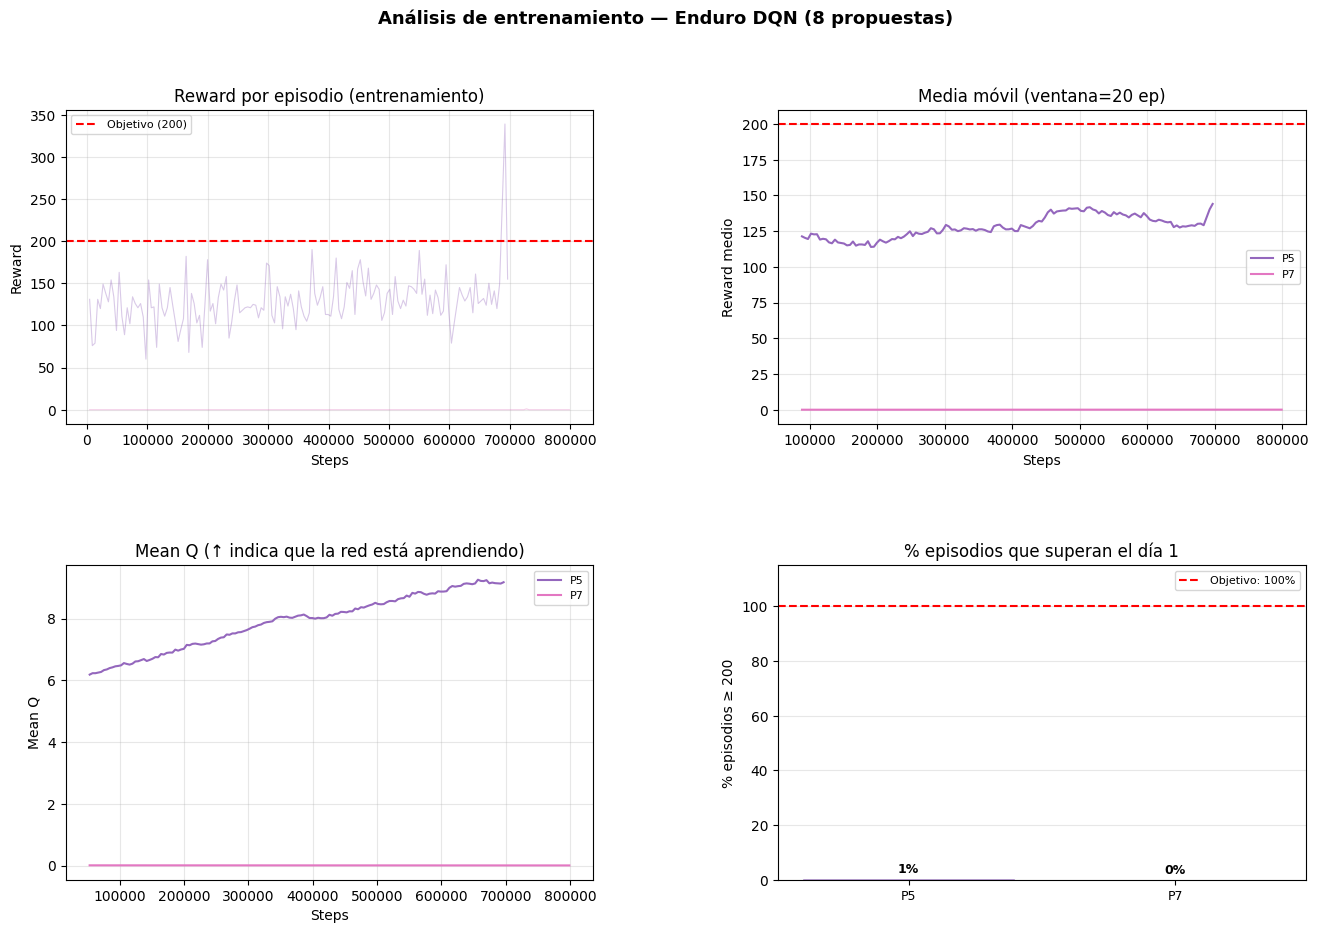

⚠️  Datos de ENTRENAMIENTO (con exploración activa) — no son el test oficial.
   Los rewards de test suelen ser más altos.
   Para el criterio real usa la celda de test de la mejor propuesta.


In [24]:
# ═══════════════════════════════════════════════════════════════════════
# ANÁLISIS COMPLETO DE TODAS LAS PROPUESTAS
# Lee directamente desde Drive: logs JSON + checkpoints guardados.
# No necesita GPU. Ejecutar en cualquier momento para ver el estado actual.
# ═══════════════════════════════════════════════════════════════════════
import json, glob, re
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

REWARD_THRESHOLD = 200  # coches necesarios para completar el día 1 en Enduro
WINDOW_ROLLING   = 20   # ventana de media móvil en las gráficas

# ── 1. Recopilar información de cada propuesta ──────────────────────────
def get_proposal_info(key, info):
    result = {
        'key':                  key,
        'checkpoints':          [],
        'last_step':            0,
        'log':                  None,
        'log_path':             None,
    }

    # ── Checkpoints ──────────────────────────────────────────────────────
    # Buscamos archivos .h5f.index dentro de info['dir']
    ckpt_pattern = os.path.join(info['dir'], f"{info['prefix']}_weights_*.h5f.index")
    for path in glob.glob(ckpt_pattern):
        m = re.search(r'_weights_(\d+)\.h5f\.index$', path)
        if m:
            result['checkpoints'].append(int(m.group(1)))
    result['checkpoints'].sort()
    if result['checkpoints']:
        result['last_step'] = result['checkpoints'][-1]

    # ── Log JSON ─────────────────────────────────────────────────────────
    # Nombre del log: dqn_{env_name}_{key}_log.json  dentro de info['dir']
    log_path = os.path.join(info['dir'], f"dqn_{env_name}_{key}_log.json")
    result['log_path'] = log_path
    if os.path.exists(log_path):
        try:
            with open(log_path) as f:
                result['log'] = json.load(f)
        except Exception as e:
            print(f"  [AVISO] No se pudo leer el log de {key}: {e}")

    return result

proposals = {k: get_proposal_info(k, v) for k, v in AGENTS_REGISTRY.items()}

# ── 2. Tabla resumen ────────────────────────────────────────────────────
print()
print("═"*82)
print("  RESUMEN DE ESTADO — TODAS LAS PROPUESTAS")
print("═"*82)
print(f"  {'':4} {'Ckpts':>5} {'Último ckpt':>12} {'Ep log':>7} "
      f"{'Media':>7} {'Std':>6} {'%>=200':>7} {'Tendencia':>12} {'Epsilon':>10}")
print("  " + "─"*80)

for key, p in proposals.items():
    n_ckpt    = len(p['checkpoints'])
    last_step = p['last_step']
    d         = p['log']

    if d is None or len(d.get('episode_reward', [])) == 0:
        print(f"  {key.upper():4} {n_ckpt:>5} {last_step:>12,}  {'— sin log o sin episodios —':>55}")
        continue

    r   = np.array(d['episode_reward'])
    n   = len(r)
    pct = 100 * (r >= REWARD_THRESHOLD).sum() / n

    q     = max(1, n // 4)
    delta = r[-q:].mean() - r[:q].mean()
    tend  = "📈 SUBE" if delta > 10 else ("📉 BAJA" if delta < -10 else "➡ ESTABLE")

    eps_str = ''
    for attr in ('mean_eps', 'mean_tau'):
        if attr in d:
            vals = [x for x in d[attr] if x == x]
            if vals:
                label = 'eps' if attr == 'mean_eps' else 'tau'
                eps_str = f"{label}:{vals[0]:.3f}→{vals[-1]:.3f}"

    print(f"  {key.upper():4} {n_ckpt:>5} {last_step:>12,} {n:>7} "
          f"{r.mean():>7.1f} {r.std():>6.1f} {pct:>6.0f}% "
          f"{tend:>12} {eps_str:>10}")

print("═"*82)

# ── 3. Diagnóstico detallado ────────────────────────────────────────────
print()
print("═"*82)
print("  DIAGNÓSTICO DETALLADO")
print("═"*82)

for key, p in proposals.items():
    d = p['log']
    print(f"\n  {key.upper()} ──────────────────────────────────────────────")

    # Checkpoints
    if not p['checkpoints']:
        print("    ⚠️  Sin checkpoints — no ha superado el primer intervalo de guardado")
    else:
        print(f"    ✓  Checkpoints: {p['checkpoints']} (último: step {p['last_step']:,})")

    # Log
    if d is None:
        print("    ⚠️  Sin log JSON — la celda de entrenamiento no se ejecutó todavía")
        continue

    r = np.array(d['episode_reward'])
    n = len(r)

    if n < 5:
        print(f"    ⚠️  Solo {n} episodio(s) — prácticamente sin entrenar")
        if n == 1:
            print(f"        Primer reward: {r[0]:.0f} | steps: {d['nb_steps'][0]:,}")
        continue

    # Inicio del log
    primer = d['nb_steps'][0]
    ultimo = d['nb_steps'][-1]
    if primer < 10000:
        print(f"    ℹ️  Log arranca desde cero (primer nb_steps={primer:,})")
    else:
        print(f"    ℹ️  Log arranca reanudando (primer nb_steps={primer:,})")
    print(f"    ℹ️  Episodios en log: {n} | Hasta step: {ultimo:,}")

    # Reward stats
    pct = 100 * (r >= REWARD_THRESHOLD).sum() / n
    print(f"    ℹ️  Reward: media={r.mean():.1f}  std={r.std():.1f}  "
          f"min={r.min():.0f}  max={r.max():.0f}  %>=200: {pct:.0f}%")

    # Mejor racha consecutiva
    mejor = racha = 0
    for rv in r:
        racha = racha + 1 if rv >= REWARD_THRESHOLD else 0
        mejor = max(mejor, racha)
    emoji = "✅" if mejor >= 100 else ("🔶" if mejor >= 20 else "❌")
    print(f"    {emoji}  Mejor racha consecutiva >= {REWARD_THRESHOLD}: "
          f"{mejor} episodios  (objetivo: 100)")

    # Epsilon / tau
    for attr, label in [('mean_eps', 'eps'), ('mean_tau', 'tau')]:
        if attr in d:
            vals = [x for x in d[attr] if x == x]
            if vals:
                print(f"    ℹ️  {label}: {vals[0]:.4f} → {vals[-1]:.4f}")
                if label == 'eps' and vals[-1] > 0.25:
                    print(f"    ❌  Epsilon final alto ({vals[-1]:.3f}) — "
                          f"reduce nb_steps a 300000 en OffsetLinearAnnealedPolicy")
                elif label == 'eps' and vals[-1] <= 0.15:
                    print(f"    ✓   Epsilon ya cerca del mínimo ({vals[-1]:.3f})")

    # mean_q
    if 'mean_q' in d:
        qv = [x for x in d['mean_q'] if x == x]
        if len(qv) >= 2:
            tend_q = "subiendo ✓" if qv[-1] > qv[0] * 1.05 else "bajando ⚠️"
            print(f"    ℹ️  mean_q: {qv[0]:.3f} → {qv[-1]:.3f}  ({tend_q})")

    # Loss
    if 'loss' in d:
        lv = [x for x in d['loss'] if x == x]
        if len(lv) >= 2:
            tend_l = "bajando ✓" if lv[-1] < lv[0] * 0.95 else "estable/subiendo"
            print(f"    ℹ️  loss:   {lv[0]:.5f} → {lv[-1]:.5f}  ({tend_l})")

print()

# ── 4. Gráficas ─────────────────────────────────────────────────────────
props_graf = {k: p for k, p in proposals.items()
              if p['log'] and len(p['log'].get('episode_reward', [])) >= 5}

if not props_graf:
    print("No hay suficientes datos para graficar todavía.")
else:
    COLORS = ['#1f77b4','#ff7f0e','#2ca02c','#d62728',
              '#9467bd','#8c564b','#e377c2','#7f7f7f']
    color_map = {k: COLORS[i % len(COLORS)] for i, k in enumerate(proposals)}

    fig = plt.figure(figsize=(16, 10))
    gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)

    # Gráfica 1: reward crudo
    ax1 = fig.add_subplot(gs[0, 0])
    for key, p in props_graf.items():
        r = np.array(p['log']['episode_reward'])
        s = np.array(p['log']['nb_steps'])
        ax1.plot(s, r, alpha=0.35, color=color_map[key], linewidth=0.8)
    ax1.axhline(REWARD_THRESHOLD, color='red', linestyle='--', linewidth=1.5,
                label=f'Objetivo ({REWARD_THRESHOLD})')
    ax1.set_title('Reward por episodio (entrenamiento)')
    ax1.set_xlabel('Steps')
    ax1.set_ylabel('Reward')
    ax1.legend(fontsize=8)
    ax1.grid(alpha=0.3)

    # Gráfica 2: media móvil
    ax2 = fig.add_subplot(gs[0, 1])
    for key, p in props_graf.items():
        r = np.array(p['log']['episode_reward'])
        s = np.array(p['log']['nb_steps'])
        if len(r) >= WINDOW_ROLLING:
            rm = np.convolve(r, np.ones(WINDOW_ROLLING) / WINDOW_ROLLING, mode='valid')
            ax2.plot(s[WINDOW_ROLLING - 1:], rm, label=key.upper(),
                     color=color_map[key], linewidth=1.5)
    ax2.axhline(REWARD_THRESHOLD, color='red', linestyle='--', linewidth=1.5)
    ax2.set_title(f'Media móvil (ventana={WINDOW_ROLLING} ep)')
    ax2.set_xlabel('Steps')
    ax2.set_ylabel('Reward medio')
    ax2.legend(fontsize=8)
    ax2.grid(alpha=0.3)

    # Gráfica 3: mean_q
    ax3 = fig.add_subplot(gs[1, 0])
    for key, p in props_graf.items():
        if 'mean_q' not in p['log']:
            continue
        qv = [x for x in p['log']['mean_q'] if x == x]
        sv = p['log']['nb_steps']
        if len(qv) > 1:
            s_q = sv[len(sv) - len(qv):]
            ax3.plot(s_q, qv, label=key.upper(), color=color_map[key], linewidth=1.5)
    ax3.set_title('Mean Q (↑ indica que la red está aprendiendo)')
    ax3.set_xlabel('Steps')
    ax3.set_ylabel('Mean Q')
    ax3.legend(fontsize=8)
    ax3.grid(alpha=0.3)

    # Gráfica 4: barras % >= 200
    ax4 = fig.add_subplot(gs[1, 1])
    claves = list(props_graf.keys())
    pcts   = [100 * (np.array(props_graf[k]['log']['episode_reward']) >= REWARD_THRESHOLD).mean()
              for k in claves]
    bars   = ax4.bar(range(len(claves)), pcts,
                     color=[color_map[k] for k in claves], edgecolor='white')
    ax4.axhline(100, color='red', linestyle='--', linewidth=1.5, label='Objetivo: 100%')
    ax4.set_xticks(range(len(claves)))
    ax4.set_xticklabels([k.upper() for k in claves], fontsize=9)
    ax4.set_ylabel('% episodios ≥ 200')
    ax4.set_title('% episodios que superan el día 1')
    ax4.set_ylim(0, 115)
    ax4.legend(fontsize=8)
    ax4.grid(alpha=0.3, axis='y')
    for bar, pct in zip(bars, pcts):
        ax4.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
                 f'{pct:.0f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

    plt.suptitle('Análisis de entrenamiento — Enduro DQN (8 propuestas)',
                 fontsize=13, fontweight='bold')
    plt.show()

print("⚠️  Datos de ENTRENAMIENTO (con exploración activa) — no son el test oficial.")
print("   Los rewards de test suelen ser más altos.")
print("   Para el criterio real usa la celda de test de la mejor propuesta.")


---